In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from scipy.stats import binomtest, ttest_ind, chi2_contingency, chisquare, f_oneway
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from pandas.api.types import CategoricalDtype

df = pd.read_csv("train_data.csv")
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
train_set.head()

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
91348,108635,15606267,Wilson,622,France,Female,35.0,7,98640.74,2,1.0,1.0,110457.99,1
2636,147941,15644891,Pirozzi,752,France,Female,32.0,2,0.00,1,1.0,0.0,159843.24,0
117007,88744,15702464,Watson,710,France,Male,31.0,4,0.00,3,0.0,0.0,160548.66,1
100279,125789,15701605,L?,704,Germany,Male,46.0,4,138912.17,1,0.0,1.0,141804.78,1
34835,135997,15757577,Hs?,675,Germany,Female,51.0,8,143390.51,1,1.0,0.0,168034.90,1


On va ce mettre comme objectif un score f1 de 67% minimum.

Avant de commencer il faut s'assurer de voir si il n'y a pas de valeur manquante.

In [62]:
df.isnull().sum()

ID                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Il n'y a pas de valeur manquante. Passons à l'analyse de la target.

In [63]:
train_set["Exited"].value_counts()

Exited
0    90564
1    24299
Name: count, dtype: int64

On voit que les deux classes de la target sont assez désiquilibré et c'est pour cette raison qu'on utilisera la métrique f1_score. On va d'abords utiliser un modéle de régréssion logistique pour un premier modéle.

##I) Définition des variables

•   Customer ID : Un identifiant unique pour chaque client (discret).

•   Surname : Le nom de famille du client (discret).

•   Credit Score : Une valeur numérique représentant le score de crédit du client (continue)

•   Geography : Le pays où réside le client (France, Spain ou Germany) (discret)

•   Gender : Le genre du client (Male or Female) (discret)

•   Age : L’âge du client (C'est une variable discréte mais qu'on va traiter comme une variable continue)

•   Tenure : Le nombre d’années pendant lesquelles le client est avec la banque (discret)

•   Balance : Le solde du compte du client (continue)

•   NumOfProducts : Le nombre de produits bancaires utilisés par le client (par exemple, compte d’épargne, carte de crédit) (discret)

•   HasCrCard : Si le client possède une carte de crédit (1 = oui, 0 = non) (discret)

•   IsActiveMember : Si le client est un membre actif (1 = oui, 0 = non) (discret)

•   EstimatedSalary : Le salaire estimé du client (continue)

•   Exited : Si le client a résilié (1 = oui, 0 = non) (discret)

•   Pour la définition des lignes, c'est les clients de la banque.

Même si les deux premiére variable ne sont pas importantes pour le modéle, rien ne coût quand même de les analyser.

In [64]:
train_set["CustomerId"].value_counts()

CustomerId
15682355    87
15570194    75
15793331    67
15585835    67
15585067    65
            ..
15743225     1
15641189     1
15743073     1
15582275     1
15727317     1
Name: count, Length: 20150, dtype: int64

Contrairement à ce que on pourrait penser, les Id des clients ne sont pas uniques dans ce dataset ce qui est normale car par exemple si un client résilié sont compte et que un autre client ouvre un compte, peut-être que le nouveau client va avoir le même ID.

In [65]:
train_set["Surname"].value_counts()

Surname
Hsia           1651
T'ien          1594
Hs?            1120
Kao            1104
Maclean        1099
               ... 
Ekwueme           1
Bellew            1
Bogolyubova       1
Wyckoff           1
Parks             1
Name: count, Length: 2707, dtype: int64

Il y a plusieurs le même nom de famille comme si il y avait justement des famille entiére dans cette banque. Une famille avec 1651 membre est quasi impossible, il y a donc un probléme. On va maintenant voir si pour chaque combinaison d'ID et de nom de famille il y a une seul ligne unique.

<Axes: xlabel='CustomerId,Surname'>

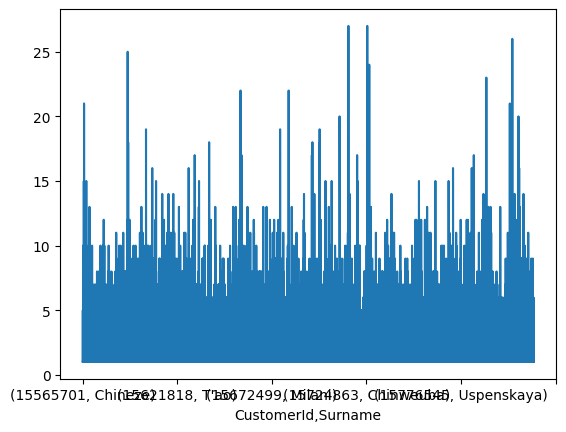

In [66]:
train_set.groupby("CustomerId")["Surname"].value_counts().plot()

Ce graphique nous montre clairement qu'il n'y a pas une ligne unique par combinaison ID et nom de famille. On va donc essayer de faire en sorte que chaque ligne correspond à un seule client.

In [67]:
num_cols = test_set[
    ["Age", "Balance", "CreditScore", "EstimatedSalary", "NumOfProducts", "Tenure"]
].columns.difference(["CustomerId"])
cat_cols = test_set[
    ["Exited", "HasCrCard", "IsActiveMember", "Gender", "Geography"]
].columns.difference(["Surname"])


def _mode(s: pd.Series):
    modes = s.mode(dropna=True)
    return modes.iat[0] if not modes.empty else np.nan


agg_funcs = {c: "mean" for c in num_cols}
agg_funcs.update({c: _mode for c in cat_cols})

# Agrégation par (ID, Nom)
test_set = test_set.groupby(["CustomerId", "Surname"], as_index=False).agg(agg_funcs)

# ARRONDIR à l’unité les colonnes numériques
test_set[num_cols] = (
    test_set[num_cols].round(0).astype("Int64")
)  # garde les NaN éventuels

# (optionnel) tri & export
test_set = test_set.sort_values(["CustomerId", "Surname"])
test_set

,CustomerId,Surname,Age,Balance,CreditScore,EstimatedSalary,NumOfProducts,Tenure,Exited,Gender,Geography,HasCrCard,IsActiveMember
0,15565706,Akobundu,37,0,682,83256,1,1,0,Male,France,1.0,1.0
1,15565706,McGregor,34,0,564,53584,2,8,0,Male,France,0.0,1.0
2,15565714,Yermakov,38,152390,595,87834,1,2,0,Male,France,1.0,1.0
3,15565759,Uwakwe,59,106590,700,185600,1,8,1,Female,France,1.0,0.0
4,15565796,Toscani,20,0,577,154776,1,2,0,Male,France,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26372,15815615,Hs?,54,147292,702,56785,1,4,0,Female,France,1.0,1.0
26373,15815620,Okwuoma,24,76954,516,27366,1,9,0,Male,France,0.0,0.0
26374,15815640,Maclean,53,95712,660,57544,1,2,1,Female,France,1.0,1.0
26375,15815645,Corrie,41,165272,635,60729,1,2,0,Male,France,1.0,1.0


In [68]:
num_cols = train_set[
    ["Age", "Balance", "CreditScore", "EstimatedSalary", "NumOfProducts", "Tenure"]
].columns.difference(["CustomerId"])
cat_cols = train_set[
    ["Exited", "HasCrCard", "IsActiveMember", "Gender", "Geography"]
].columns.difference(["Surname"])


def _mode(s: pd.Series):
    modes = s.mode(dropna=True)
    return modes.iat[0] if not modes.empty else np.nan


agg_funcs = {c: "mean" for c in num_cols}
agg_funcs.update({c: _mode for c in cat_cols})

# Agrégation par (ID, Nom)
train_set = train_set.groupby(["CustomerId", "Surname"], as_index=False).agg(agg_funcs)

# ARRONDIR à l’unité les colonnes numériques
train_set[num_cols] = (
    train_set[num_cols].round(0).astype("Int64")
)  # garde les NaN éventuels

# (optionnel) tri & export
train_set = train_set.sort_values(["CustomerId", "Surname"])
train_set

,CustomerId,Surname,Age,Balance,CreditScore,EstimatedSalary,NumOfProducts,Tenure,Exited,Gender,Geography,HasCrCard,IsActiveMember
0,15565701,Chineze,32,107210,705,129823,1,6,0,Male,France,1.0,1.0
1,15565701,Ferri,39,161994,698,90212,1,2,0,Female,France,1.0,0.0
2,15565706,Akobundu,35,0,663,83256,1,4,1,Male,Spain,1.0,1.0
3,15565706,Chung,39,124577,699,160593,2,5,0,Male,Germany,1.0,0.0
4,15565714,Cattaneo,47,64430,601,96518,2,1,0,Male,Spain,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95356,15815690,Ch'iu,51,106302,661,85889,1,5,1,Male,Germany,1.0,0.0
95357,15815690,Iweobiegbulam,45,0,620,192744,2,5,0,Male,France,0.0,1.0
95358,15815690,K'ung,51,103176,707,171091,1,3,0,Male,Germany,1.0,1.0
95359,15815690,Madukaego,31,0,652,151315,2,1,0,Female,France,1.0,1.0


##II) Analyse statistiques

#II.1) Analyse univarié

1) Analyse des variables discrétes

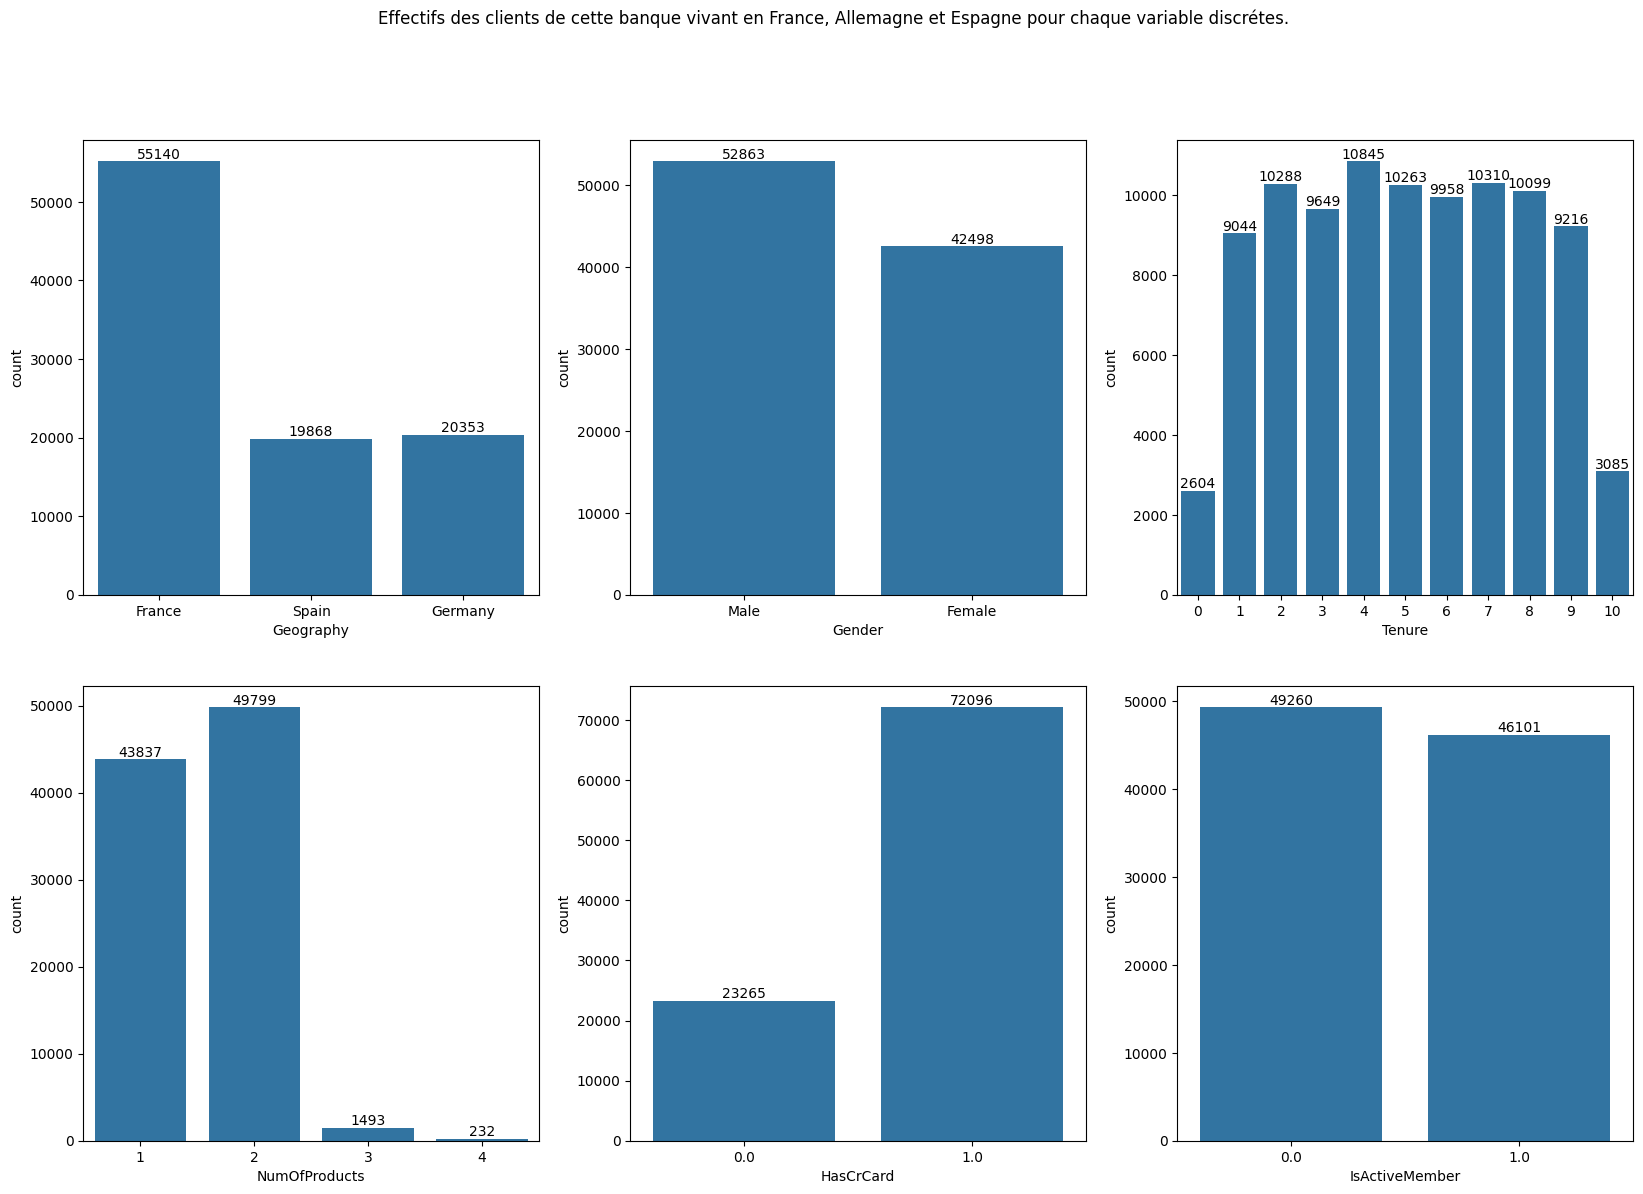

In [69]:
fig, ax = plt.subplots(2, 3)
plt.suptitle(
    "Effectifs des clients de cette banque vivant en France, Allemagne et Espagne pour chaque variable discrétes."
)
fig.set_size_inches(20, 13)
sns.countplot(data=train_set, x="Geography", ax=ax[0, 0])
sns.countplot(data=train_set, x="Gender", ax=ax[0, 1])
sns.countplot(data=train_set, x="Tenure", ax=ax[0, 2])
sns.countplot(data=train_set, x="NumOfProducts", ax=ax[1, 0])
sns.countplot(data=train_set, x="HasCrCard", ax=ax[1, 1])
sns.countplot(data=train_set, x="IsActiveMember", ax=ax[1, 2])
for ax_i in ax:
    for ax_ii in ax_i:
        for container in ax_ii.containers:
            ax_ii.bar_label(container)
plt.show()

a) Geography

Nous observons qu'il y a une majorité de client qui vive en France et qu'il y a un nombre similaire de client qui vive en allemagne et en Espagne. On va essayer de tester la différences de nombre de client entre l'Espagne et l'Allemagne avec un test d'hypothése. On peut émettre comme hypothése que la banque est peut-être une banque Française mais on ne peut pas le prouver avec nos données.

b) Genre

On remarque qu'il y a plus d'homme que de femme dans cette banque. Pour être sur que cette différence est généralisable sur toutes la population, on va faire un test d'hypothése.

c) Tenure

On remarque que pour des tenures de 0 et 10 on a moins de clients que pour les autres années mais cela peut s'expliquer par le fait que pour la tenure égale à 10, l'étude à commencer durant l'année en cours et pour une valeur de 0, l'année en cours n'ai pas terminé. Pour le reste des tenures, les nombres de clients fluctue mais reste relativement constant.

d) Nombre de produits

On a plus de clients qui ont 2 produit que 1 produit même si les effectifs sont similaires. On va essayer de tester cette similitudes avec un test d'hypothése. On observe qu'il y a vraiment peu de client qui ont 3 et 4 produits. On peut émettre l'hypothése que la banque à une mauvaise stratégie marketing concernant certains produits. Cela ne peut pas être expliqué par nos donnée.

e) Possession d'une carte de crédit

Il y a clairement plus de clients possédant une carte de crédit. Ceci s'explique que beaucoup de clients ont besoin de payer à crédits. 

f) Status d'activité

On observe qu'il y a un nombre similaire de client actifs que inactifs. On vérifiera cettte similitudes avec un test d'hypothése.

a) Geography

Maintenant on va faire des tests d'hypothéses afin de généraliser les observations précédentes à toutes la population. On va d'abords vérifier que le nombre de clients vivant en Allemagne n'est pas le même que ceux qui vive en Espagne.

In [70]:
print("H0: Il y a le même nombre de client vivant en Allemagne et en Espagne.")

alpha = 0.02

data_test = train_set.query("`Geography` != 'France'")

k = data_test["Geography"].value_counts()["Spain"]

n = len(data_test)

p_value = binomtest(k=k, n=n).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il y a le même nombre de client vivant en Allemagne et en Espagne.
Nous avons assez d'évidence pour rejeter H0.


Comme on a rejeter H0, on peut dire avec un seuil alpha de 2% que le nombre de client vivant en Allemagne et en Espagne est différent. 

b) Genre

On va essayer de prouver que la différence observer est bien significatif.

In [71]:
print("H0: Il y a le même nombre de femmes que d'homme.")

alpha = 0.02

k = train_set["Gender"].value_counts()["Female"]

n = len(train_set)

p_value = binomtest(k=k, n=n).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il y a le même nombre de femmes que d'homme.
Nous avons assez d'évidence pour rejeter H0.


Sans surprise l'hypothése H0 à été rejeter. On peut donc dire avec une seuil alpha de 2% qu'il y a bien plus d'hommes que de femmes dans cette banque. 

c) Nombre de produit

On va essayer de tester la différence entre le nombre de client qui ont 1 et ceux qui ont 2 produit.

In [72]:
print("H0: Il y a le même nombre de clients qui ont 1 et 2 produit.")

alpha = 0.02

data_test = train_set.query("`NumOfProducts` < 3")

k = data_test["NumOfProducts"].value_counts()[1]

n = len(data_test)

p_value = binomtest(k=k, n=n).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il y a le même nombre de clients qui ont 1 et 2 produit.
Nous avons assez d'évidence pour rejeter H0.


Comme on a rejeter H0 on peut donc dire avec un seuil alpha de 2% que le nombre de clients qui ont 1 et 2 produit est différent. 

d) Possession d'une carte de crédit

On va tester si la grande différence entre les clients qui posséde une carte de crédit et ceux qui n'en posséde pas est généralisable sur toutes la population.

In [73]:
print(
    "H0: Il y a le même nombre de client qui posséde une carte de crédit que ceux qui n'en posséde pas."
)

alpha = 0.02

k = train_set["HasCrCard"].value_counts()[0]

n = len(train_set)

p_value = binomtest(k=k, n=n).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il y a le même nombre de client qui posséde une carte de crédit que ceux qui n'en posséde pas.
Nous avons assez d'évidence pour rejeter H0.


Sans surprise l'hypothése H0 est rejeter. On peut donc dire avec un seuil alpha de 2% qu'il y a bien plus de client qui ont une carte de crédit que ceux qui n'en ont pas.

e) Status d'activité

On va essayer de tester si il y a autant de client qui sont actif que ceux qui ne sont pas actifs.

In [74]:
print("H0: Il y a le même nombre de client actifs que inactif.")

alpha = 0.02

k = train_set["IsActiveMember"].value_counts()[0]

n = len(train_set)

p_value = binomtest(k=k, n=n).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il y a le même nombre de client actifs que inactif.
Nous avons assez d'évidence pour rejeter H0.


Comme l'hypothése H0 n'est pas rejeter on peut donc dire que tant qu'il n'y a pas une preuve du contraire, le nombre de client actifs de cette banque est identiques à ceux qui sont inactifs.

2) Analyse des variables continues

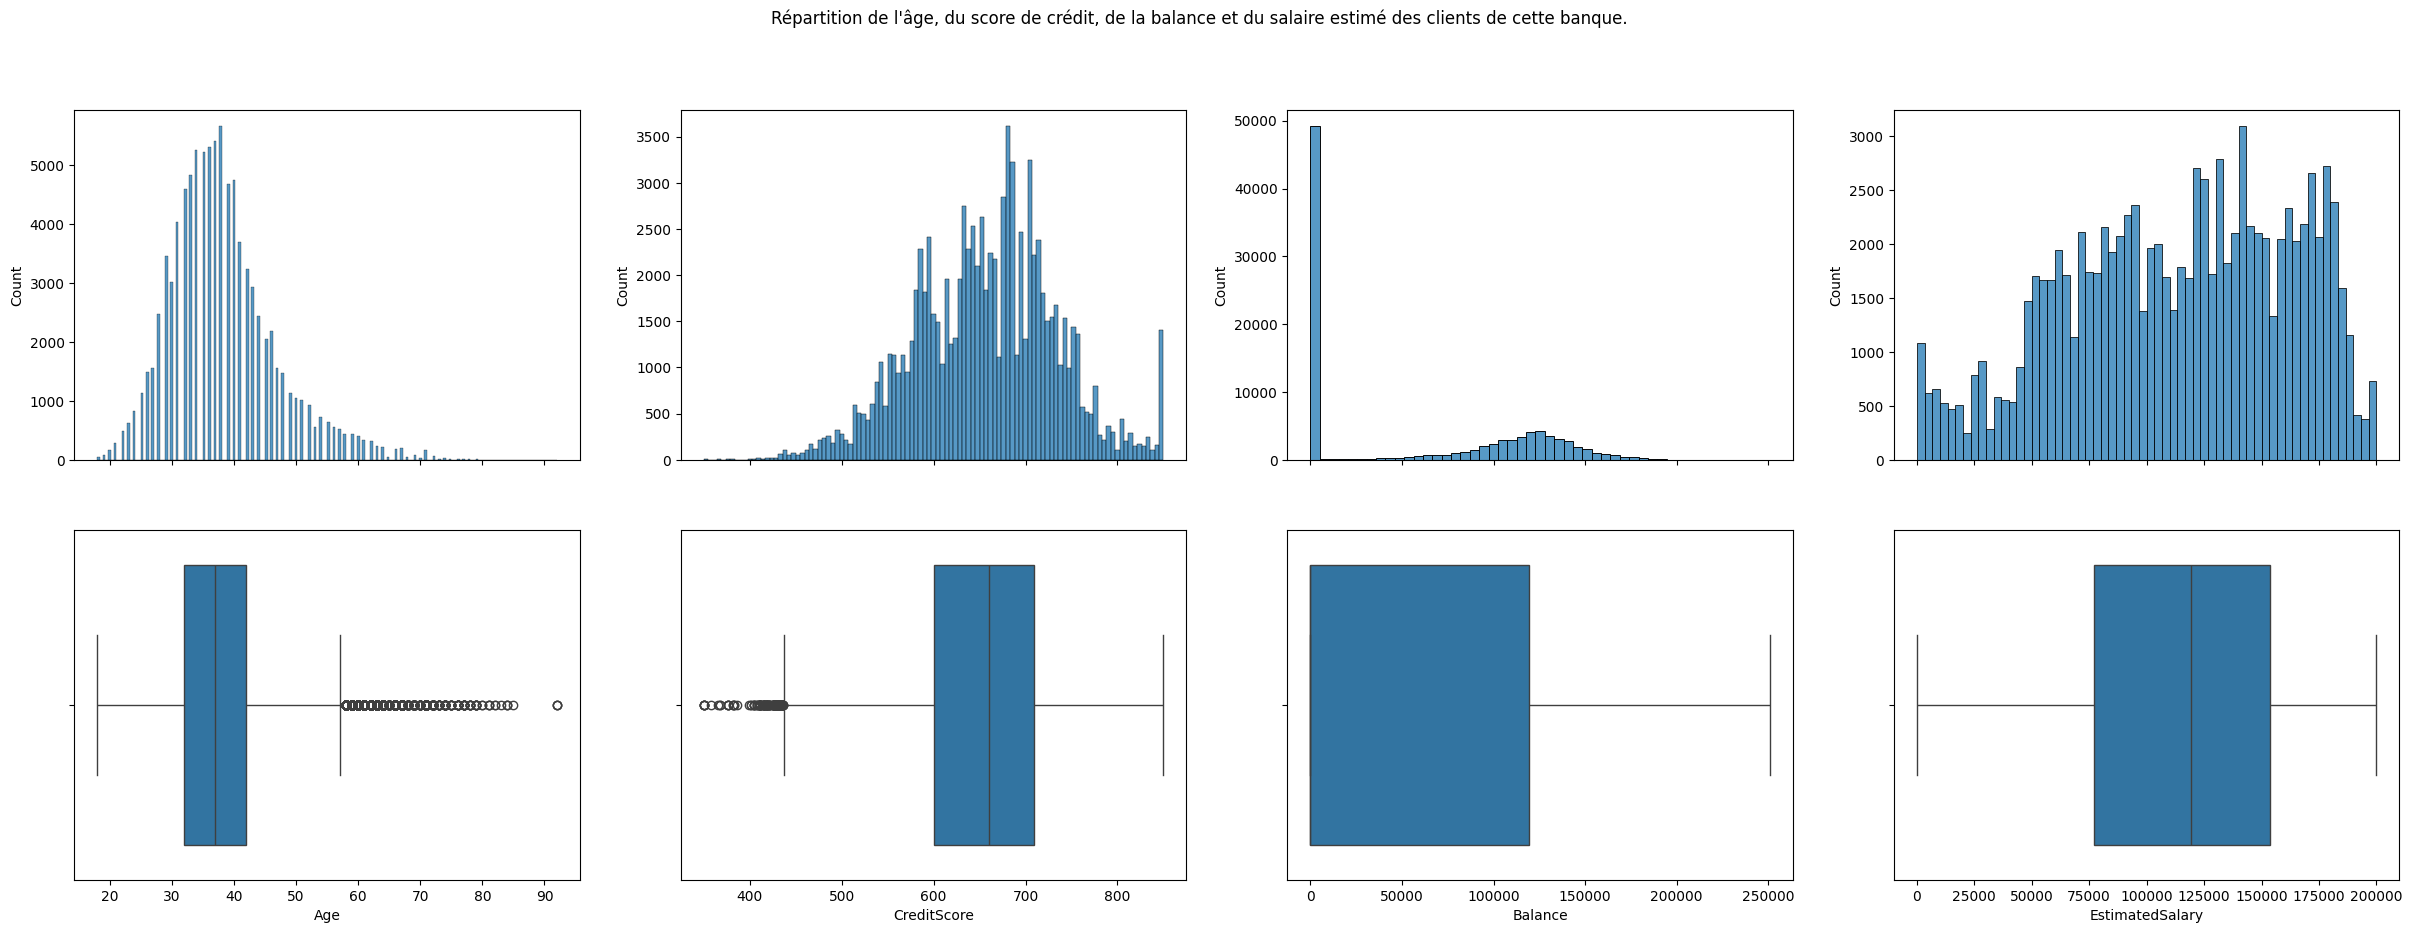

,Age,CreditScore,Balance,EstimatedSalary
count,95361.0,95361.0,95361.0,95361.0
mean,38.112625,656.947285,56562.512285,113465.561624
std,8.539365,76.791066,61834.410083,48684.176762
min,18.0,350.0,0.0,12.0
25%,32.0,600.0,0.0,77142.0
50%,37.0,660.0,0.0,119110.0
75%,42.0,709.0,119278.0,153625.0
max,92.0,850.0,250898.0,199992.0


In [75]:
fig, ax = plt.subplots(2, 4, sharex="col")
fig.set_size_inches(30, 10)
plt.suptitle(
    "Répartition de l'âge, du score de crédit, de la balance et du salaire estimé des clients de cette banque."
)
sns.histplot(data=train_set, x="Age", ax=ax[0, 0])
sns.boxplot(data=train_set, x="Age", ax=ax[1, 0])
sns.histplot(data=train_set, x="CreditScore", ax=ax[0, 1])
sns.boxplot(data=train_set, x="CreditScore", ax=ax[1, 1])
sns.histplot(data=train_set, x="Balance", ax=ax[0, 2])
sns.boxplot(data=train_set, x="Balance", ax=ax[1, 2])
sns.histplot(data=train_set, x="EstimatedSalary", ax=ax[0, 3])
sns.boxplot(data=train_set, x="EstimatedSalary", ax=ax[1, 3])
plt.show()

train_set[["Age", "CreditScore", "Balance", "EstimatedSalary"]].describe()

a) Age

On voit que la moyenne d'âge des clients de cette banque vivant en France, en Allemagne et en Espagne est de 38 ans avec un écart-type de 8.87 ans. Le minimum est de 18 ans ce sui est normale car l'âge minimum pour les trois pays pour avoir un compte bancaire. La médiane est de 37 ans. Le client le plus âgé à 92 ans qui est peut-être un client qui est décédé et il faut vérifier cela en regardant si sont compte est actif ou pas. On observe que l'âge suit une loi normale et que la plupart des clients ont entre 28 et 50 ans. On observe aussi qu'il y a des outliers à droite de la boxplot.

b) Score de crédit

Le score de crédit est une variable qui évalue la fiabilité d'un clients. Plus le score est bas, moins le client est fiable. La moyenne des score de crédit des clients de cette banque qui vive en France, en Allemagne et en Espagne est de 656.50 qui est un score plutôt moyen. L'écart-type est de 80.18. Le score minmum est de 350 et maximum est de 850 et la médiane est à 659. On voit que le score de crédit suit une loi normale et que la plupart des clients ont un score entre 550 et 750. On observe quelques outliers à gauche de la boxplot.

c) La balance 

La moyenne des balances des clients de cette banque vivant en France, en Allemagne et en Espagne est de 55624.55 euros avec un écart-type de 62825.06 euros. La balance minimum est à 0 euros, le maximum à 250898.09 euros et la médiane à 0 euros. On voit que la plupart des clients ont une balance égale à 0 et que les balance différent de 0 forme une loi normale. L'éxistence de balance égale à 0 n'est pas étrange car quand on créer un compte bancaire, la balance est de 0. Il peut avoir plusieurs raison d'avoir une balance égale à 0 et on essayera de trouver les différentes raison pour voir si il y a une relation entre ces différentes raisons et la target.

d) Le salaire

Avant d'analyser les statistiques on voit que le salaire minimum est de 11.58 euros ce qui est impossible. On voit aussi que la plupart des salaires sont trés élevé. Il y a donc plusieur types de salaire ce qui rend cette variable inutilisable. On peut quand même essayer de corriger cette variable mais on ne le fera pas pour le premier essaie.

#II.2) Analyse de chaque variable avec la target

1) Analyse des variables dicrétes en fonction de la target

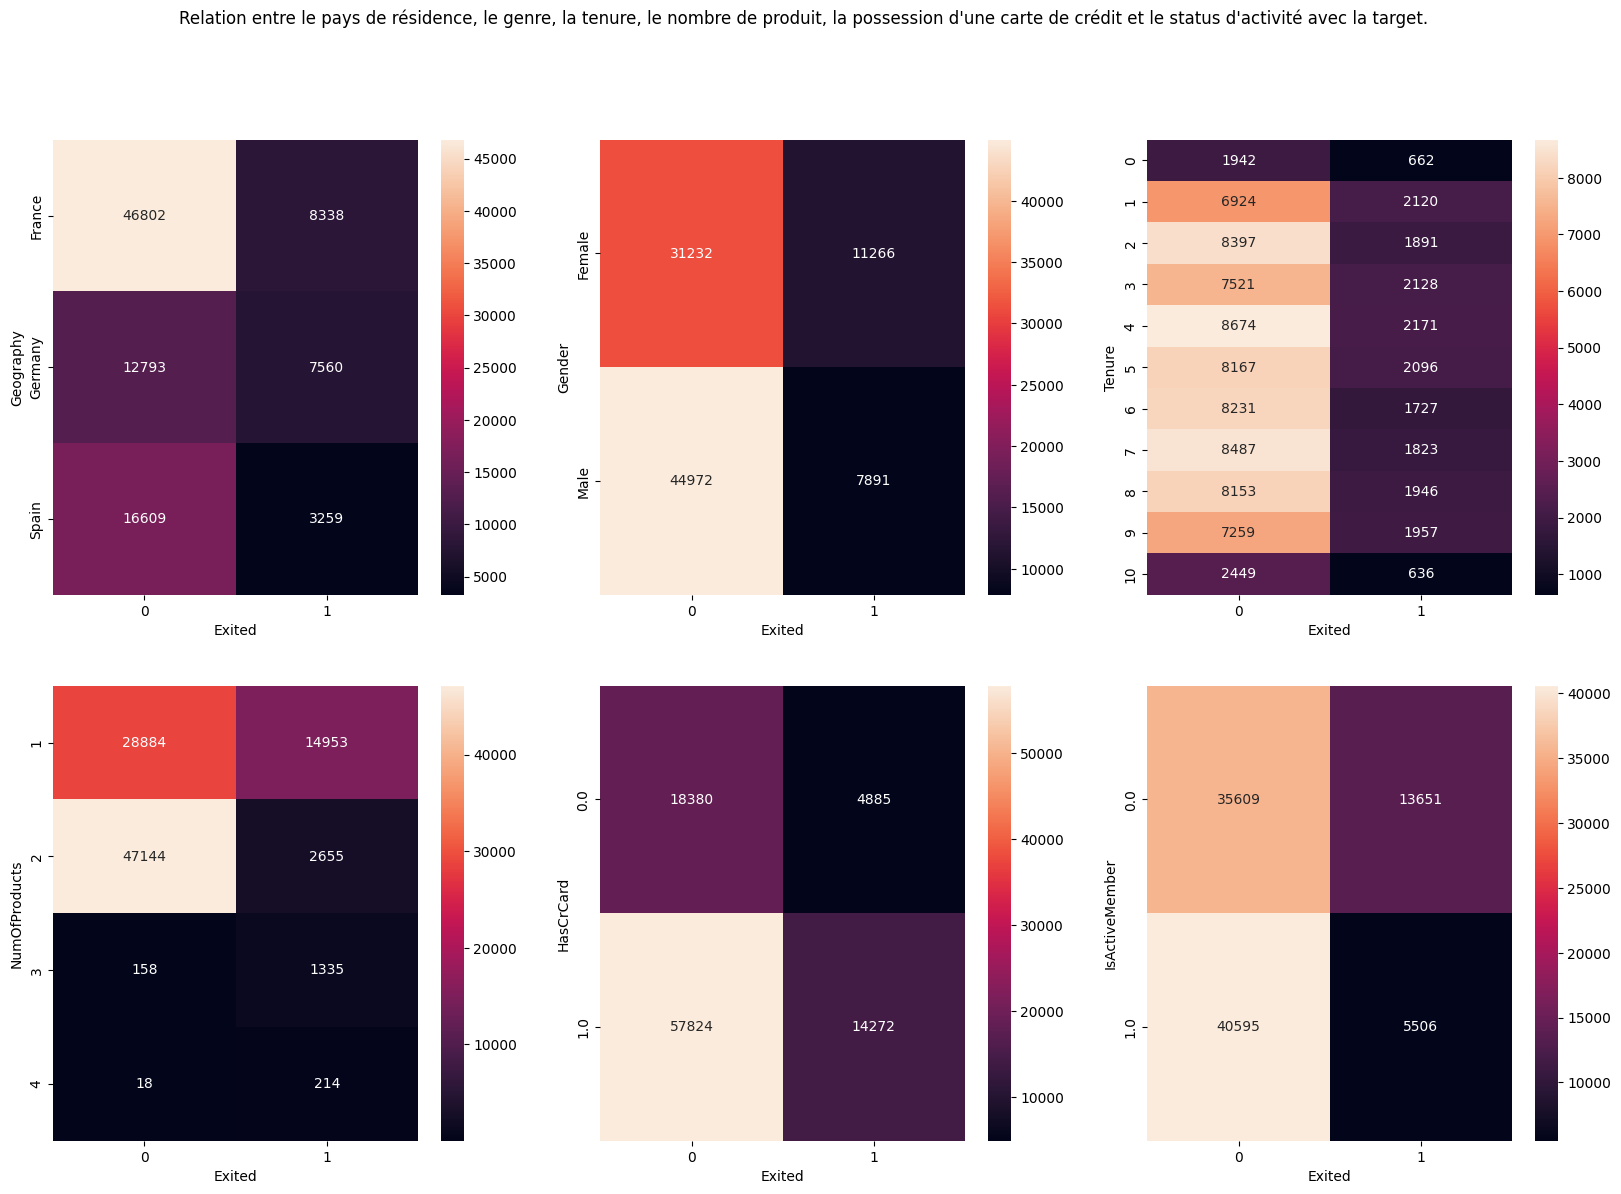

In [76]:
fig, ax = plt.subplots(2, 3)
plt.suptitle(
    "Relation entre le pays de résidence, le genre, la tenure, le nombre de produit, la possession d'une carte de crédit et le status d'activité avec la target."
)
fig.set_size_inches(20, 13)
sns.heatmap(
    pd.crosstab(train_set["Geography"], train_set["Exited"]),
    annot=True,
    fmt="d",
    ax=ax[0, 0],
)
sns.heatmap(
    pd.crosstab(train_set["Gender"], train_set["Exited"]),
    annot=True,
    fmt="d",
    ax=ax[0, 1],
)
sns.heatmap(
    pd.crosstab(train_set["Tenure"], train_set["Exited"]),
    annot=True,
    fmt="d",
    ax=ax[0, 2],
)
sns.heatmap(
    pd.crosstab(train_set["NumOfProducts"], train_set["Exited"]),
    annot=True,
    fmt="d",
    ax=ax[1, 0],
)
sns.heatmap(
    pd.crosstab(train_set["HasCrCard"], train_set["Exited"]),
    annot=True,
    fmt="d",
    ax=ax[1, 1],
)
sns.heatmap(
    pd.crosstab(train_set["IsActiveMember"], train_set["Exited"]),
    annot=True,
    fmt="d",
    ax=ax[1, 2],
)
plt.show()

a) Geography

On remarque que pour les deux classes de la target, la majorité des clients vive en France. On observe aussi que la différence de client entre la France et l'Allemagne est beaucoup plus grand pour les clients qui n'ont pas résilié par rapport à ceux qui ont résilié. On observe qu'il y a plus de client qui vive en Allemagne qu'en Espagne pour les clients qui ont résilié et c'est le contraire pour les clients qui n'ont pas résilié. En résumer la seule observation importante est qu'il y a plus de client qui ont résilié leurs compte qui vive en Allemagne qu'en Espagne. 

b) Genre

On voit qu'il y a plus de femmes qui ont résilié que d'homme et c'est l'inverse pour les clients qui n'ont pas résilié.

c) Tenure

Le nombre de client fluctuent pour des tenures entre 1 et 9 pour les deux classes de la target. On observe que la tenure qui contient le plus grand nombre de client qui ont résilié est la valeur 4 qui n'est pas la valeur qui contient le plus de client par rapport à l'analyse univarié. On observe différentes divergences entres les deux classes de la target qui sont:

*1 -> 2: Augmentation des clients qui n'ont pas résilié et diminution des clients qui ont résilié.

*2 -> 3: Diminution des clients qui n'ont pas résilié et augmentation des clients qui ont résilié.

*7 -> 8: Diminution des clients qui n'ont pas résilié et augmentation des clients qui ont résilié.

*8 -> 9: Diminution des clients qui n'ont pas résilié et trés légére augmentation des clients qui ont résilié.

*Pour les tenures des extrêmité le nombre de client qui ont résilié leurs compte est plus grands pour une valeur de tenure de 0 que pour une valeur de 1 et c'est l'inverse pour les clients qui n'ont pas résilié leurs comptes.

Globalement ces observations sont assez difficiles à interprété et donc pour le premier essaie on ignorera la tenure.

d) Nombre de produit

On voit qu'il y a beaucoup de client qui ont résilié parmis les clients qui ont 3 et 4 produits et vraiment trés peu qui n'ont pas résilié. On pourrat donc résupérer les clients avec 3 et 4 produits. C'est comme si certains produit de la banque ne sont pas atrractif. On voit que le nombre client qui ont résilié leurs compte ont majoritairement 1 produits et ceux qui n'ont pas résilié ont majoritairement deux produits. Ils faut donc ce concentrer sur les clients qui ont un seul produit.

e) Possession carte de crédit

On observe rien de spéciale donc on ne fera pas de test d'hypothése et on ne l'utilisera pas pour le modéle.

f) Status d'activité

Il y a plus de client qui ont résilié inactif que actifs et c'est le contraire pour les clients qui n'ont pas résilé leurs compte.

Maintenant on va passer au test de chi2 de contingence pour chaque variable.

In [77]:
print("H0: Il n'y a pas de relation entre le pays de résidence et la target.")

alpha = 0.02

p_value = chi2_contingency(
    pd.crosstab(train_set["Geography"], train_set["Exited"])
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre le pays de résidence et la target.
Nous avons assez d'évidence pour rejeter H0.


In [78]:
print("H0: Il n'y a pas de relation entre le genre et la target.")

alpha = 0.02

p_value = chi2_contingency(pd.crosstab(train_set["Gender"], train_set["Exited"])).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre le genre et la target.
Nous avons assez d'évidence pour rejeter H0.


In [79]:
print("H0: Il n'y a pas de relation entre le nombre de produit et la target.")

alpha = 0.02

p_value = chi2_contingency(
    pd.crosstab(train_set["NumOfProducts"], train_set["Exited"])
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre le nombre de produit et la target.
Nous avons assez d'évidence pour rejeter H0.


In [80]:
print("H0: Il n'y a pas de relation entre le status d'activité et la target.")

alpha = 0.02

p_value = chi2_contingency(
    pd.crosstab(train_set["IsActiveMember"], train_set["Exited"])
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre le status d'activité et la target.
Nous avons assez d'évidence pour rejeter H0.


On a rejeter toutes les hypothése H0 pour les test de contingence et donc on peut dire qu'il y a bien des relations pour chaque variables dicrétes avec la target.

En conclusion pour les variables dicrétes on voit que les filtres les plus intéréssant sont les clients qui vive en Allemagne, qui sont des femmes, qui ont un seul produit et qui ont une balance différent de 0.

2) Analyse des variables continues en fonction de la target

*Analyse des moyennes

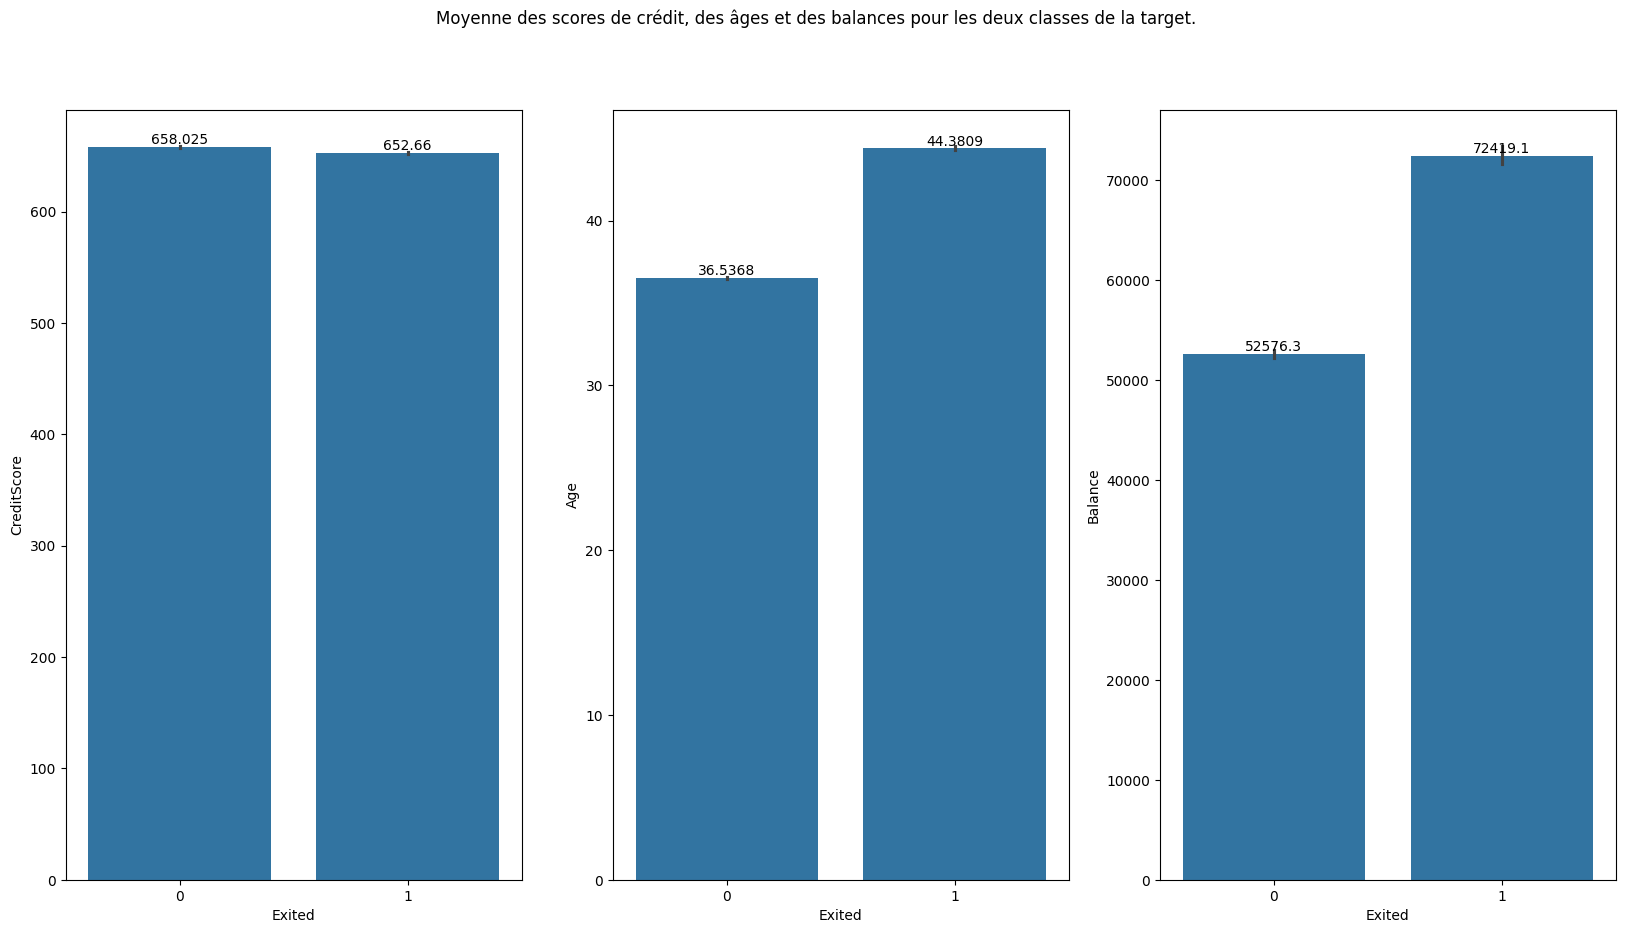

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,76204.0,658.024946,76.225972,350.0,603.0,662.0,709.0,850.0
1,19157.0,652.66049,78.855269,350.0,594.0,652.0,707.0,850.0


In [81]:
fig, ax = plt.subplots(1, 3)
plt.suptitle(
    "Moyenne des scores de crédit, des âges et des balances pour les deux classes de la target."
)
fig.set_size_inches(20, 10)
sns.barplot(data=train_set, y="CreditScore", x="Exited", ax=ax[0])
sns.barplot(data=train_set, y="Age", x="Exited", ax=ax[1])
sns.barplot(data=train_set, y="Balance", x="Exited", ax=ax[2])
for ax_i in ax:
    for container in ax_i.containers:
        ax_i.bar_label(container)
plt.show()

train_set.groupby("Exited")["CreditScore"].describe()

In [82]:
train_set.groupby("Exited")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,76204.0,36.536835,7.750439,18.0,32.0,36.0,40.0,92.0
1,19157.0,44.380905,8.653119,18.0,39.0,44.0,50.0,82.0


In [83]:
train_set.groupby("Exited")["Balance"].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,76204.0,52576.318343,61156.731163,0.0,0.0,0.0,116100.0,250898.0
1,19157.0,72419.062014,61972.592486,0.0,0.0,100655.0,125427.0,238388.0


a) Score de crédit

On observe que en moyenne les clients qui ont résilié ont un score de crédit légéremment inférieur à ceux qui n'ont pas résilié. On peut donc dire que les clients qui ont résilié sont légéremment moins fiable que les clients qui n'ont pas résilié. 

b) Age

On observe que en moyenne les clients qui ont résilié sont plus âgé que les clients qui n'ont pas résilié.

c) Balance

On observe que en moyenne les clients qui ont résilié ont une balance supérieur à ceux qui n'ont pas résilié. 

Maintenant on va faire les tests d'hypothése. Vérifions les conditions pour utiliser un test de student. On peut déjà dire qu'on ne peut pas faire un test de student pour la balance car la la balance ne suit pas une loi normale. Vérifions pour les deux autres variables.
-Un score de crédit dépends seulement du comportement du client et pas celle des autres, l'âge d'un client ne dépends pas des autres.
-Tous les clients sont issue de la même population
-On a bien plus de 30 points par groupes pour les deux variables.
-Les deux variances sont assez similaires pour les deux variables pour utiliser un test de student.

In [84]:
print("H0: Les clients qui ont résilié ont en moyenne le même score de crédit.")

alpha = 0.02

p_value = ttest_ind(
    train_set.query("`Exited` == 0")["CreditScore"],
    train_set.query("`Exited` == 1")["CreditScore"],
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Les clients qui ont résilié ont en moyenne le même score de crédit.
Nous avons assez d'évidence pour rejeter H0.


In [85]:
print(
    "H0: Les clients qui ont résilié ont en moyenne le même âge que ceux qui n'ont pas résilié."
)

alpha = 0.02

p_value = ttest_ind(
    train_set.query("`Exited` == 0")["Age"],
    train_set.query("`Exited` == 1")["Age"],
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Les clients qui ont résilié ont en moyenne le même âge que ceux qui n'ont pas résilié.
Nous avons assez d'évidence pour rejeter H0.


On voit qu'on a réussie à rejeter H0 pour le score de crédit et l'âge. On peut donc dire avec un seuil alpha de 2 % que les clients sont en moyenne moins fiable et plus âgé que les clients qui n'ont pas résilié. Cela est assez logique car un client avec un trop mauvais score de crédit peut-être mauvais pour la banque et donc la banque peut prendre l'initiative de résilié le compte. Un client avec un trop mauvais score de crédit peut aussi décider de résilié sont propre compte. Pour l'âge par contre je n'ai pas vraiment d'explication. Maintenant vérifions les répartitions de chaque variables continues pour les deux classes.

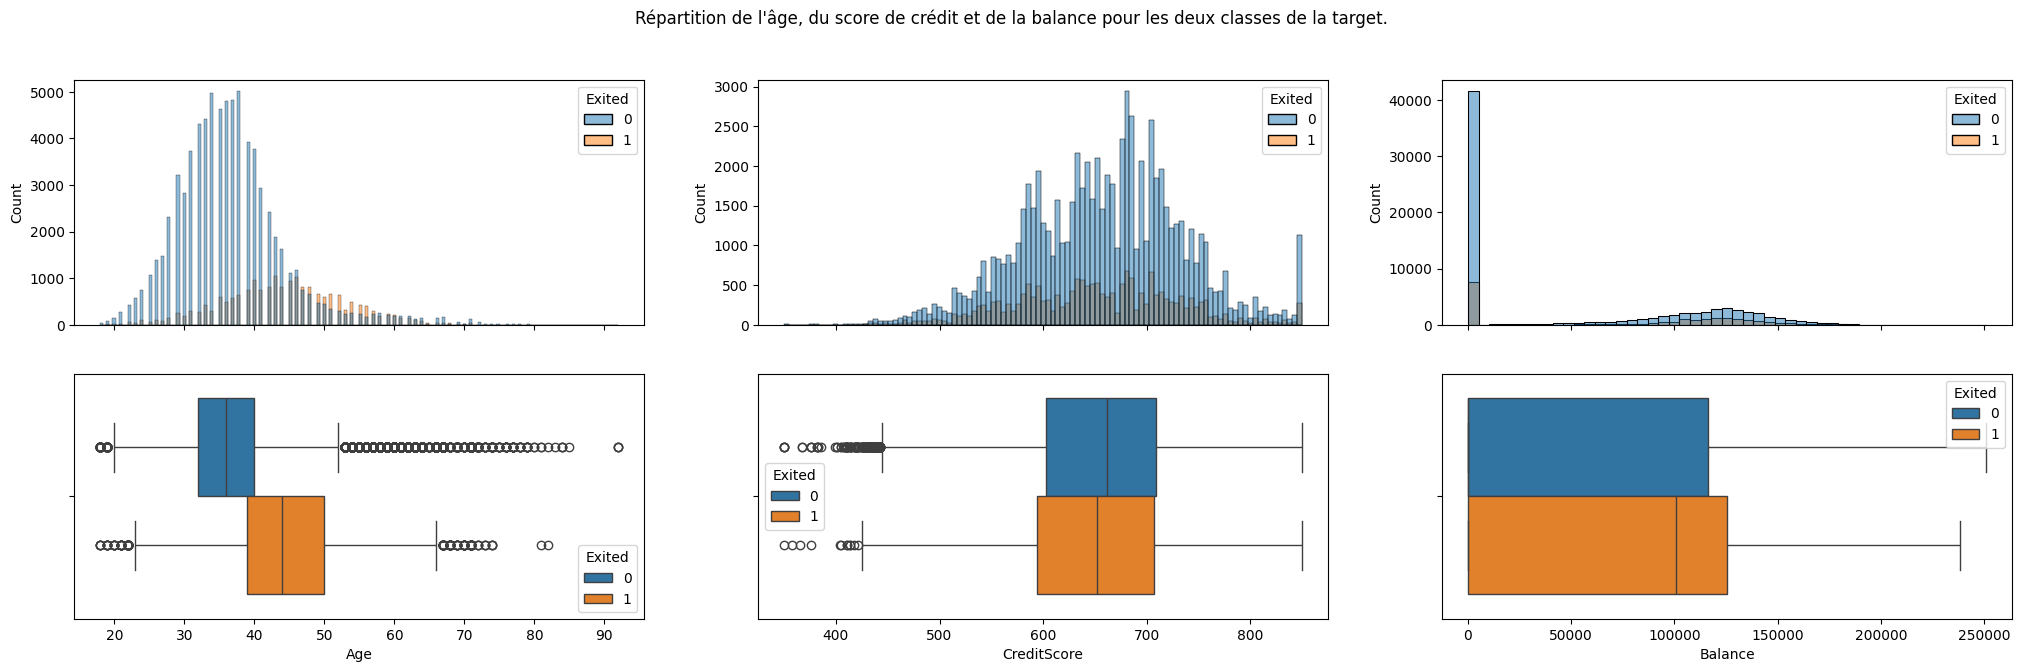

In [86]:
fig, ax = plt.subplots(2, 3, sharex="col")
fig.set_size_inches(25, 7)
plt.suptitle(
    "Répartition de l'âge, du score de crédit et de la balance pour les deux classes de la target."
)
sns.histplot(data=train_set, x="Age", hue="Exited", ax=ax[0, 0])
sns.boxplot(data=train_set, x="Age", hue="Exited", ax=ax[1, 0])
sns.histplot(data=train_set, x="CreditScore", hue="Exited", ax=ax[0, 1])
sns.boxplot(data=train_set, x="CreditScore", hue="Exited", ax=ax[1, 1])
sns.histplot(data=train_set, x="Balance", hue="Exited", ax=ax[0, 2])
sns.boxplot(data=train_set, x="Balance", hue="Exited", ax=ax[1, 2])
plt.show()

a) Age

On observe que entre 47 ans 56 ans, on a plus de client qui ont résilié que de clients qui n'ont pas résilié. On voit aussi que les deux loi normale sont décalés, il y a donc une séparation partiel. On observe aussi des outliers sur les boxplots.

b) Score de crédits

Il n'y a pas grand chose à dire, les deux répartitions sont complêtement superposé.

c) Balance

On voit que la différence de client entre les balances différent de 0 et égaux à 0 est beaucoup plus grands pour les clients qui n'ont pas résilié que pour ceux qui n'ont pas résilié ceux qui explique pourquoi la moyenne des balances des clients qui ont résilié est plus élevé que ceux qui n'ont pas résilié. Pour mieux observer les différences d'effectifs de clients qui ont une balance égal et différent de 0, on peut créer une variable binaires.

In [87]:
train_set["Binary_balance"] = np.select(
    condlist=[train_set["Balance"] != 0], choicelist=[1], default=0
)

pd.crosstab(train_set["Binary_balance"], train_set["Exited"])

Exited,0,1
Binary_balance,,
0,41502,7653
1,34702,11504


In [88]:
test_set["Binary_balance"] = np.select(
    condlist=[test_set["Balance"] != 0], choicelist=[1], default=0
)

On voit qu'il y a plus de client qui ont résilié avec une balance différent de 0 qu'avec une balance égale à 0 et c'est l'inverse avec les clients qui n'ont pas résilié. On va maintenant tester cette relation.

In [89]:
print("H0: Il n'y a pas de relation entre la balance binariser et la target.")

alpha = 0.02

p_value = chi2_contingency(
    pd.crosstab(train_set["Binary_balance"], train_set["Exited"])
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre la balance binariser et la target.
Nous avons assez d'évidence pour rejeter H0.


Comme on a rejeter H0, on peut donc dire avec un seuil alpha de 2% qu'il y a bien une relation entre les deux variables. 

On peut maintenant essayer de visualiser la seule surface continue qui est entre l'âge et le score de crédit.

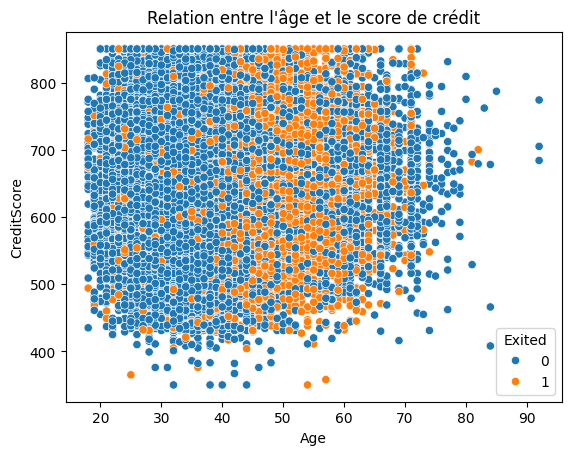

In [90]:
plt.title("Relation entre l'âge et le score de crédit")
sns.scatterplot(data=train_set, x="Age", y="CreditScore", hue="Exited")
plt.show()

On observe effectivement une zone entre 40 et 70 ans dans lequel il y a vraiment beaucoup de client qui ont résilié. On ne voit pas grand chose sur l'axe des scores de crédits. En conclusion on peut dire que même si la différence de moyenne de score de crédit est significatif, les deux répartitions sont complêtement superposé et pour l'âge on a une zone dans lequel on a plus de client qui ont résilié qui est entre 47 ans 56 ans.

#II.3) Analyse des variables entre-eux.

Dans cette section on va regarder l'effet des filtres les plus importants c'est-à-dire, les client vivant en Allemagne, les femmes, les clients qui ont un seul produit et les clients inactifs ainsi que les clients ayant une balance différent de 0 sur la surface continue du score de crédit et de l'âge. On va d'abord faire une combinaison de filtre et voir les surfaces aprés.

In [91]:
train_set_copy = train_set.copy()
train_set_copy = train_set_copy.query("`NumOfProducts` < 3")
train_set_copy["Profil"] = (
    train_set_copy["Geography"]
    + "_"  # séparateur, au choix
    + train_set_copy["Gender"]
    + "_"
    + train_set_copy["NumOfProducts"].astype(str)
    + "_"
    + train_set_copy["IsActiveMember"].astype(str)
    + "_"
    + train_set_copy["Binary_balance"].astype(str)
)

pd.crosstab(train_set_copy["Profil"], train_set_copy["Exited"])

Exited,0,1
Profil,,
France_Female_1_0.0_0,913,1932
France_Female_1_0.0_1,2180,891
France_Female_1_1.0_0,1090,701
France_Female_1_1.0_1,2379,358
France_Female_2_0.0_0,4949,344
France_Female_2_0.0_1,1236,175
France_Female_2_1.0_0,5353,141
France_Female_2_1.0_1,1002,67
France_Male_1_0.0_0,1373,1190


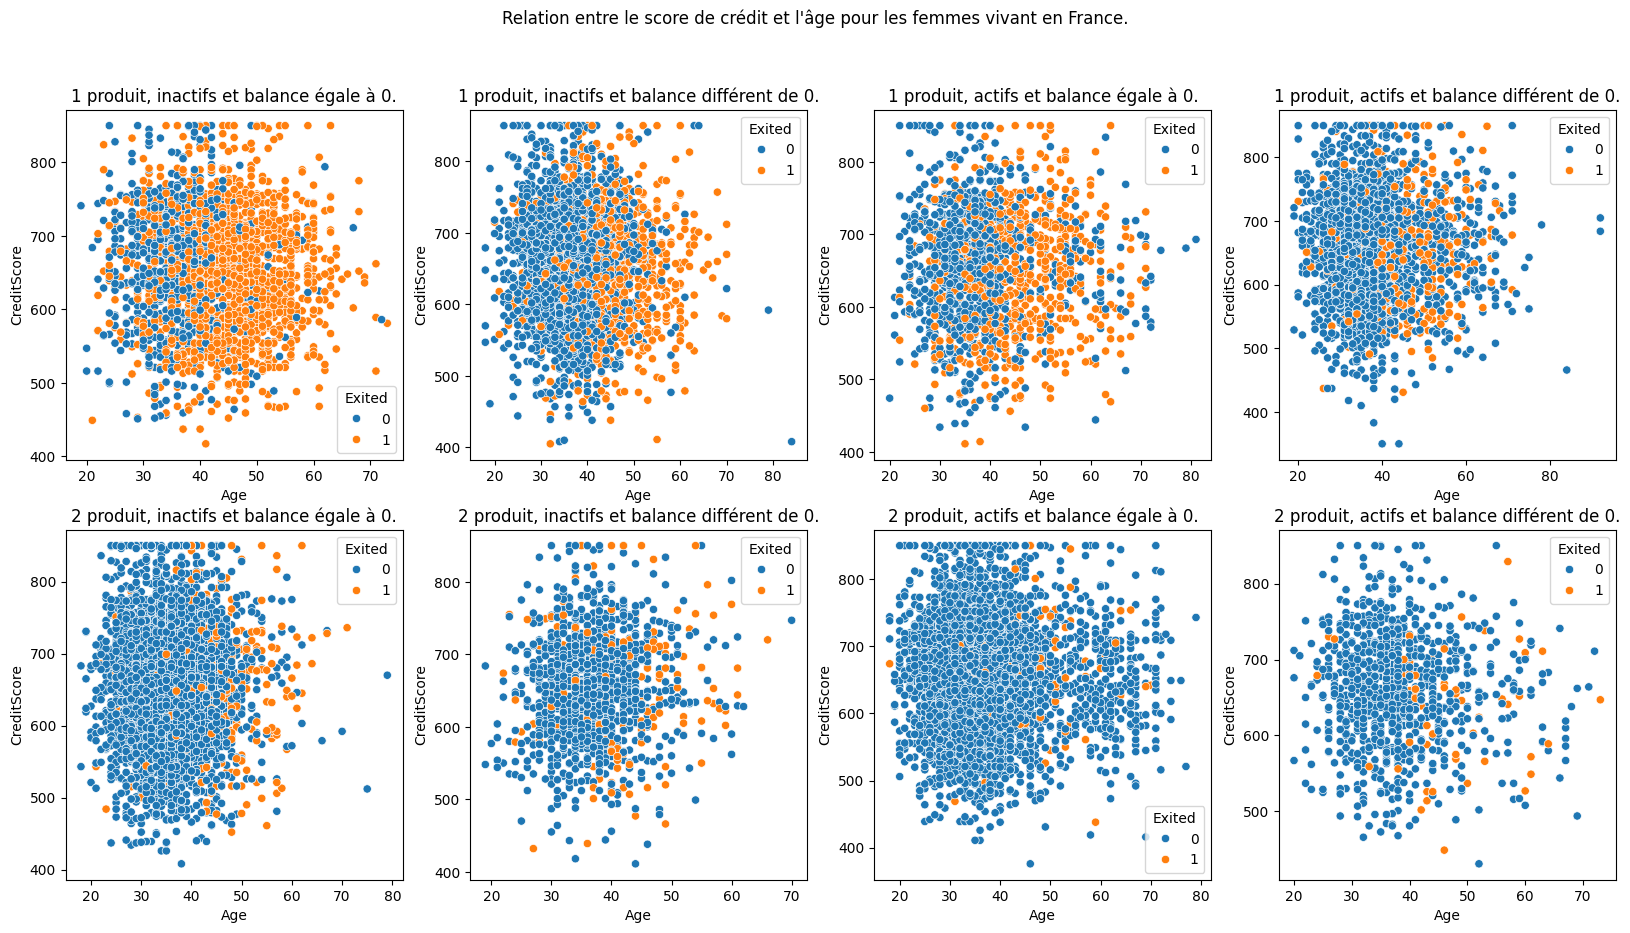

In [92]:
fig, ax = plt.subplots(2, 4)
fig.set_size_inches(20, 10)
plt.suptitle(
    "Relation entre le score de crédit et l'âge pour les femmes vivant en France."
)
ax[0, 0].set_title("1 produit, inactifs et balance égale à 0.")
ax[0, 1].set_title("1 produit, inactifs et balance différent de 0.")
ax[0, 2].set_title("1 produit, actifs et balance égale à 0.")
ax[0, 3].set_title("1 produit, actifs et balance différent de 0.")
ax[1, 0].set_title("2 produit, inactifs et balance égale à 0.")
ax[1, 1].set_title("2 produit, inactifs et balance différent de 0.")
ax[1, 2].set_title("2 produit, actifs et balance égale à 0.")
ax[1, 3].set_title("2 produit, actifs et balance différent de 0.")

sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'France_Female_1_0.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 0],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'France_Female_1_0.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 1],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'France_Female_1_1.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 2],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'France_Female_1_1.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 3],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'France_Female_2_0.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 0],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'France_Female_2_0.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 1],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'France_Female_2_1.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 2],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'France_Female_2_1.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 3],
)
plt.show()

On peut récupérer les clients ayant 1 produit, inactif et balance égale à 0 et qui ont plus de 35 ans. On peut aussi récupérer les clients qui ont 1 seul produit, inactifs et balance différent de 0 et qui ont plus de 40 ans. On peut récupérer les clients qui ont 1 seul produit, actifs et balance égale à 0 et qui ont plus de 40 ans.

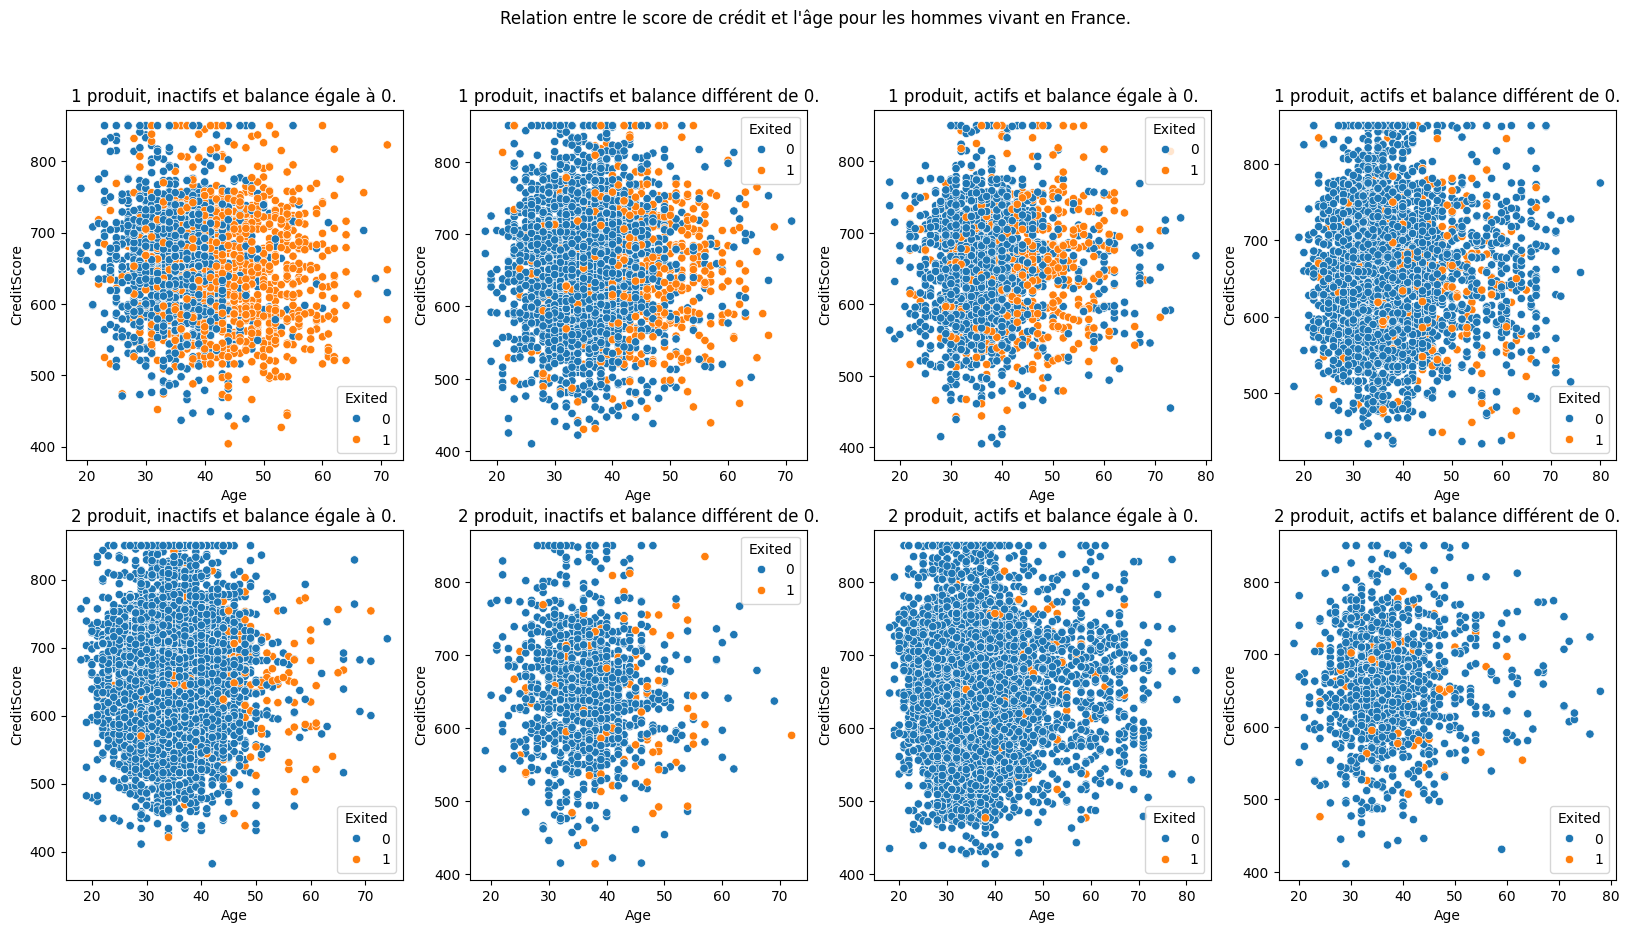

In [93]:
fig, ax = plt.subplots(2, 4)
fig.set_size_inches(20, 10)
plt.suptitle(
    "Relation entre le score de crédit et l'âge pour les hommes vivant en France."
)
ax[0, 0].set_title("1 produit, inactifs et balance égale à 0.")
ax[0, 1].set_title("1 produit, inactifs et balance différent de 0.")
ax[0, 2].set_title("1 produit, actifs et balance égale à 0.")
ax[0, 3].set_title("1 produit, actifs et balance différent de 0.")
ax[1, 0].set_title("2 produit, inactifs et balance égale à 0.")
ax[1, 1].set_title("2 produit, inactifs et balance différent de 0.")
ax[1, 2].set_title("2 produit, actifs et balance égale à 0.")
ax[1, 3].set_title("2 produit, actifs et balance différent de 0.")

sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'France_Male_1_0.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 0],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'France_Male_1_0.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 1],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'France_Male_1_1.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 2],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'France_Male_1_1.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 3],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'France_Male_2_0.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 0],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'France_Male_2_0.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 1],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'France_Male_2_1.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 2],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'France_Male_2_1.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 3],
)
plt.show()

On peut récupérer les clients qui ont 1 produit, inactifs et balance égal à 0 et qui ont plus de 40 ans. On peut aussi récupérer les clients qui ont 1 produit, inactifs et balance différent de 0 et qui ont plus de 50 ans.

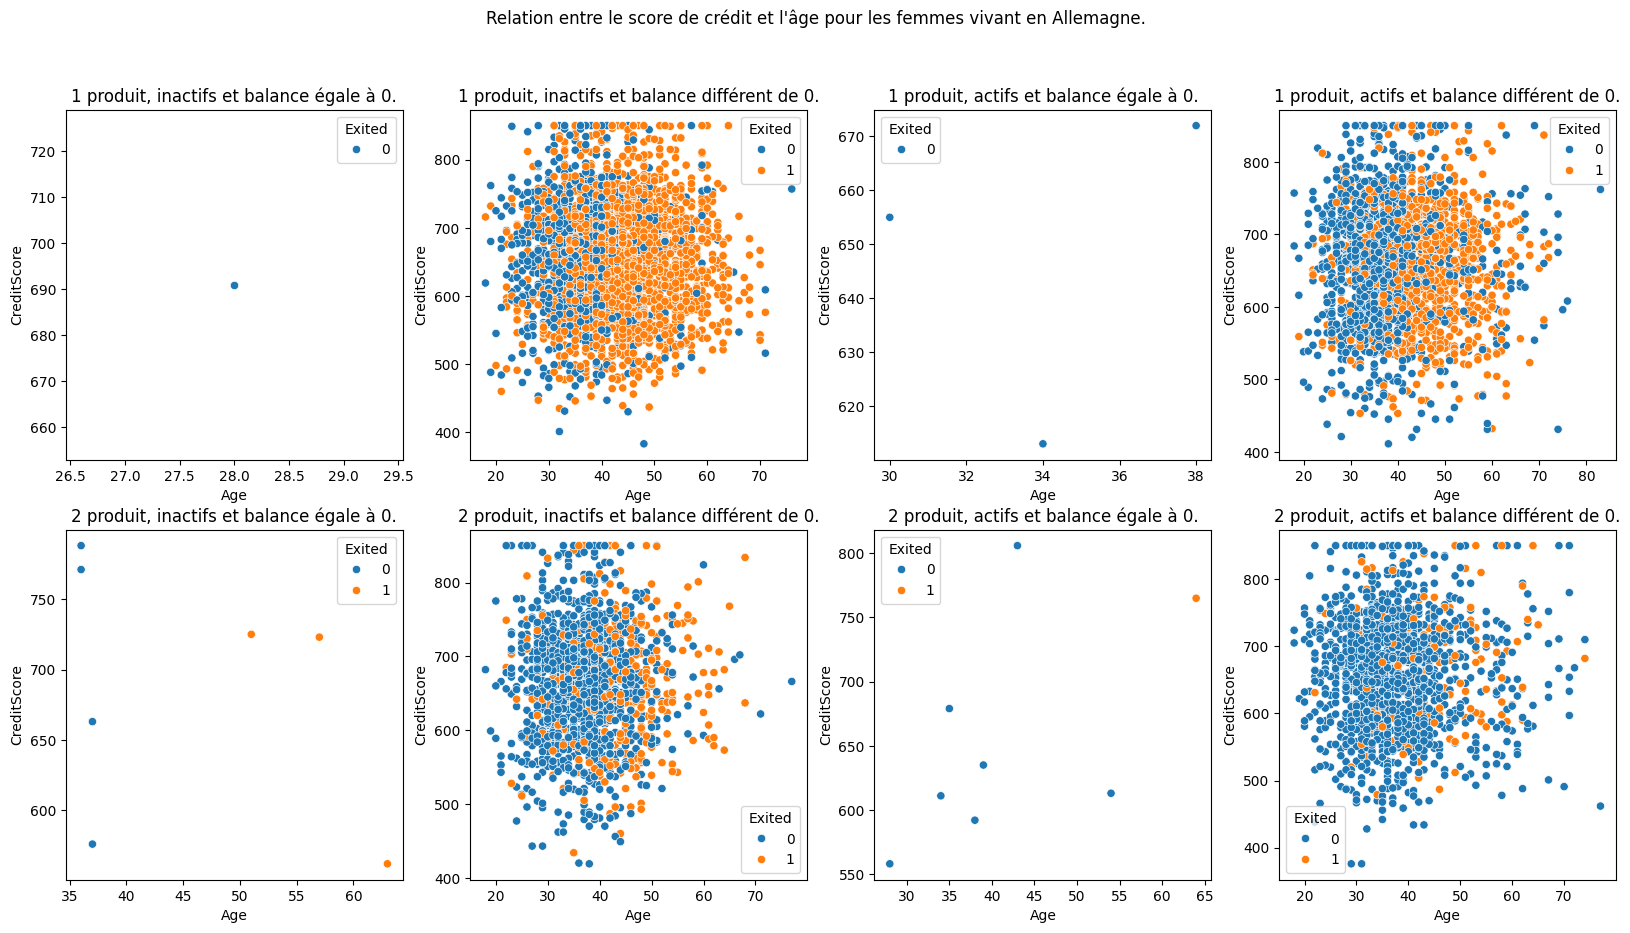

In [94]:
fig, ax = plt.subplots(2, 4)
fig.set_size_inches(20, 10)
plt.suptitle(
    "Relation entre le score de crédit et l'âge pour les femmes vivant en Allemagne."
)
ax[0, 0].set_title("1 produit, inactifs et balance égale à 0.")
ax[0, 1].set_title("1 produit, inactifs et balance différent de 0.")
ax[0, 2].set_title("1 produit, actifs et balance égale à 0.")
ax[0, 3].set_title("1 produit, actifs et balance différent de 0.")
ax[1, 0].set_title("2 produit, inactifs et balance égale à 0.")
ax[1, 1].set_title("2 produit, inactifs et balance différent de 0.")
ax[1, 2].set_title("2 produit, actifs et balance égale à 0.")
ax[1, 3].set_title("2 produit, actifs et balance différent de 0.")

sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Germany_Female_1_0.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 0],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Germany_Female_1_0.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 1],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Germany_Female_1_1.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 2],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Germany_Female_1_1.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 3],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Germany_Female_2_0.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 0],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Germany_Female_2_0.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 1],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Germany_Female_2_1.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 2],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Germany_Female_2_1.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 3],
)
plt.show()

On peut récupérer les clients qui ont 1 seul produits, inactifs et balance différent de 0 et qui ont plus de 38 ans. On peut récupérer les clients qui ont 1 seul produit, actifs et balance différent de 0 et qui ont plus de 42 ans.

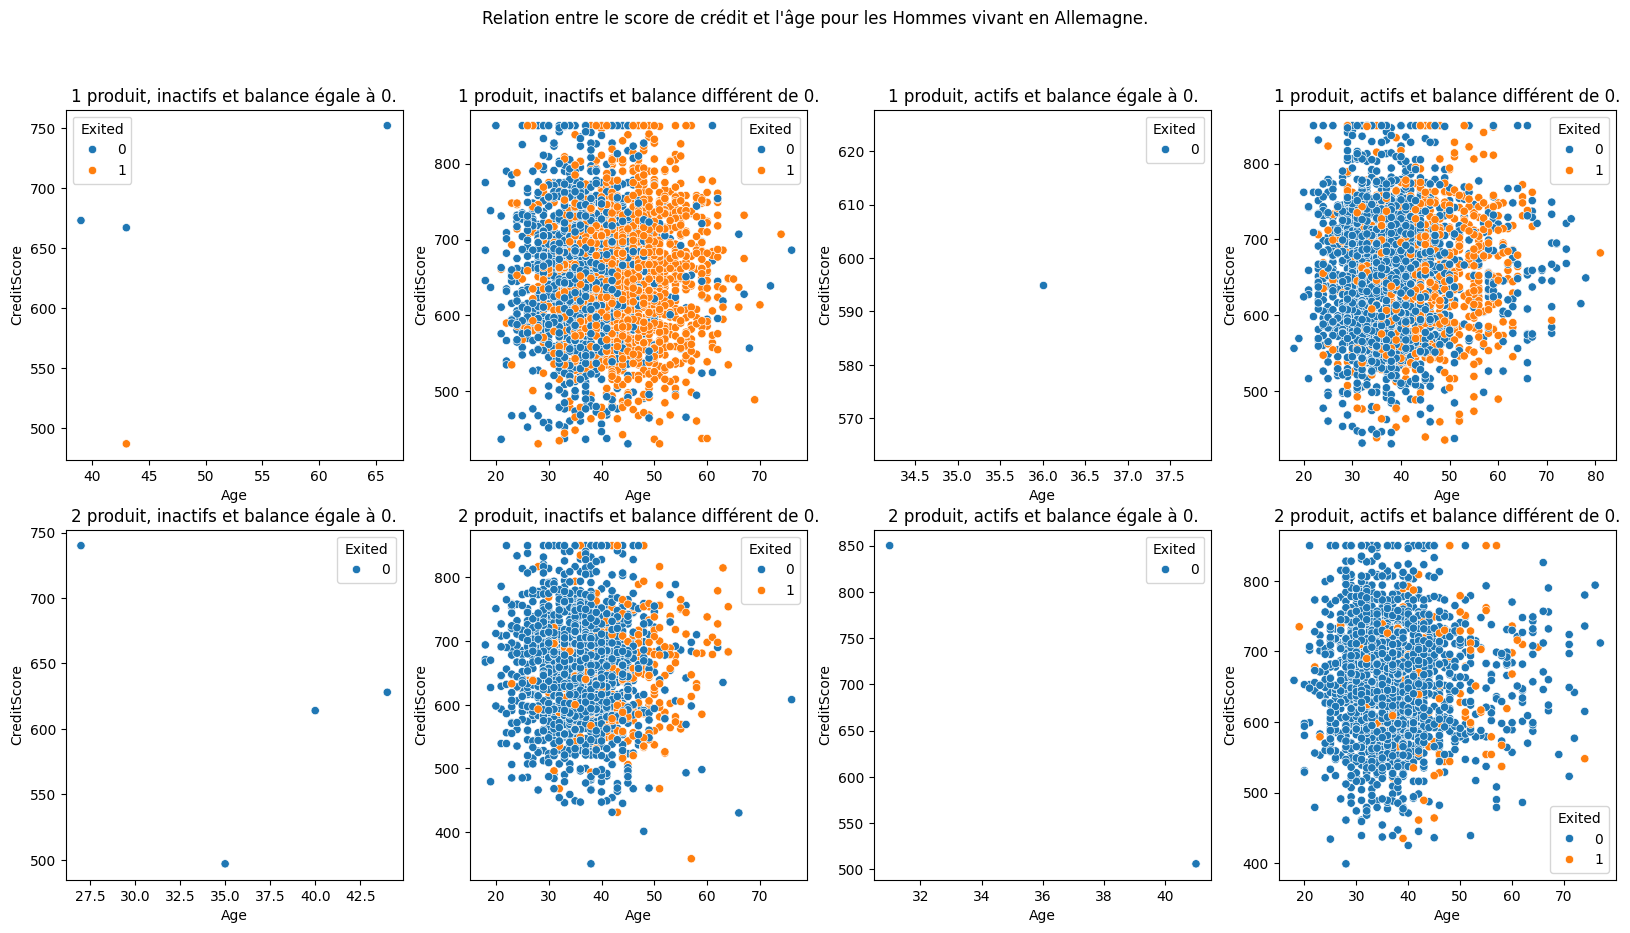

In [95]:
fig, ax = plt.subplots(2, 4)
fig.set_size_inches(20, 10)
plt.suptitle(
    "Relation entre le score de crédit et l'âge pour les Hommes vivant en Allemagne."
)
ax[0, 0].set_title("1 produit, inactifs et balance égale à 0.")
ax[0, 1].set_title("1 produit, inactifs et balance différent de 0.")
ax[0, 2].set_title("1 produit, actifs et balance égale à 0.")
ax[0, 3].set_title("1 produit, actifs et balance différent de 0.")
ax[1, 0].set_title("2 produit, inactifs et balance égale à 0.")
ax[1, 1].set_title("2 produit, inactifs et balance différent de 0.")
ax[1, 2].set_title("2 produit, actifs et balance égale à 0.")
ax[1, 3].set_title("2 produit, actifs et balance différent de 0.")

sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Germany_Male_1_0.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 0],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Germany_Male_1_0.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 1],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Germany_Male_1_1.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 2],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Germany_Male_1_1.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 3],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Germany_Male_2_0.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 0],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Germany_Male_2_0.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 1],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Germany_Male_2_1.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 2],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Germany_Male_2_1.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 3],
)
plt.show()

On peut récupérer les clients qui ont 1 seul produit, inactifs et balance différent de 0 et qui ont plus de 40 ans. On peut aussi récupérer les clients qui ont 1 seul produit, actifs et balance différent de 0 et qui ont entre 45 et 65 ans.

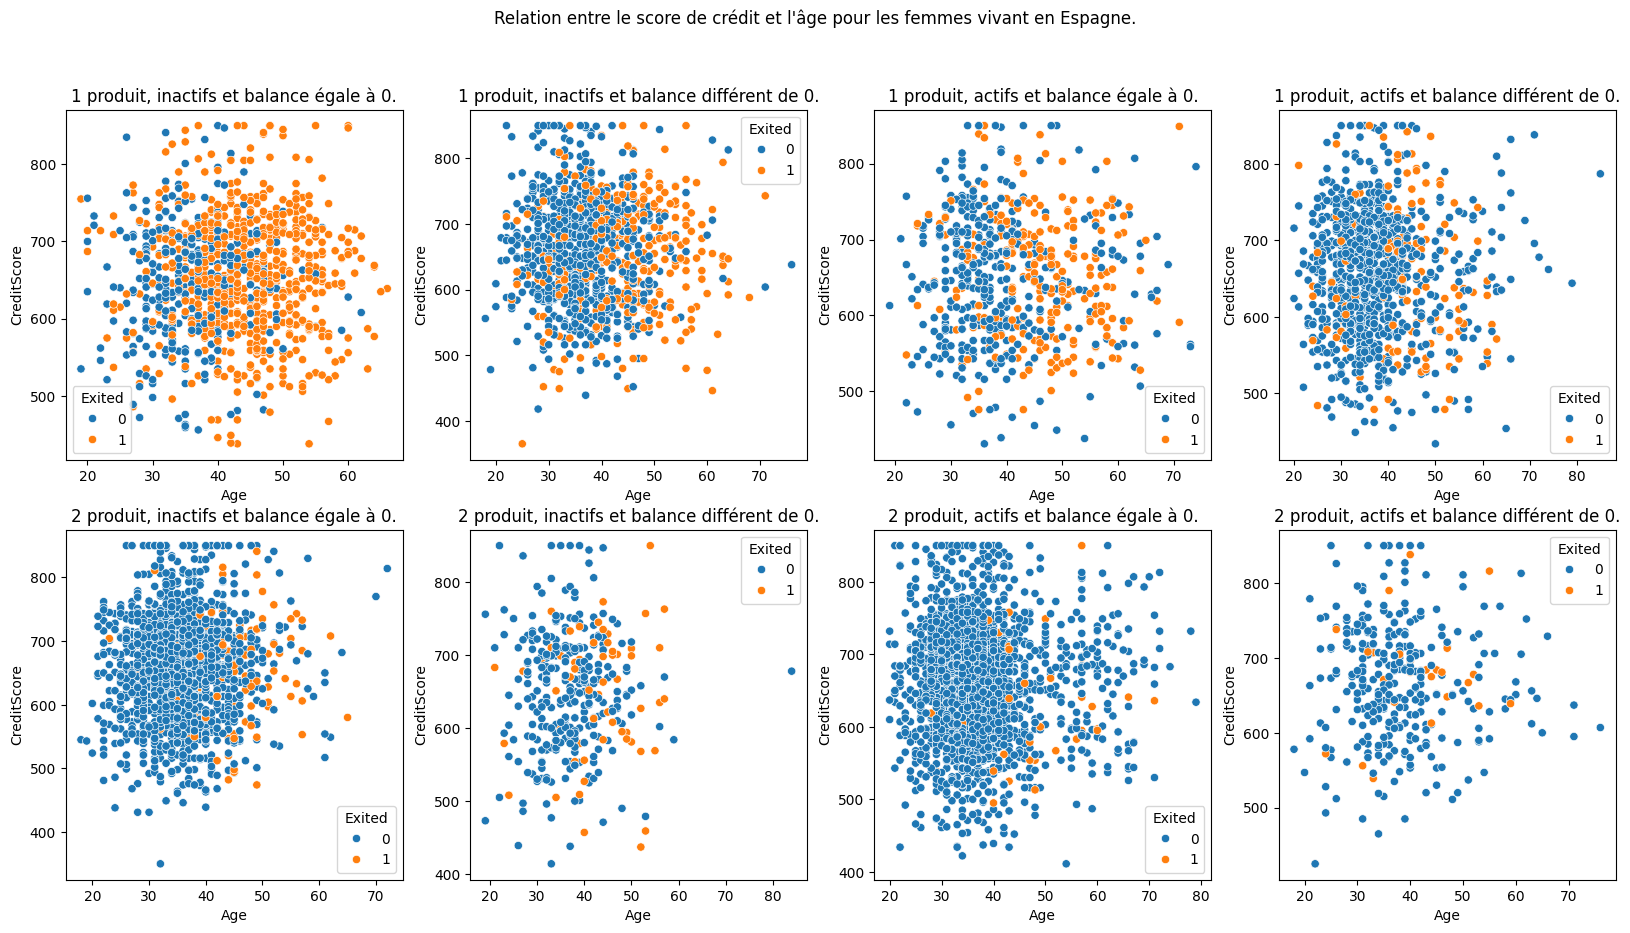

In [96]:
fig, ax = plt.subplots(2, 4)
fig.set_size_inches(20, 10)
plt.suptitle(
    "Relation entre le score de crédit et l'âge pour les femmes vivant en Espagne."
)
ax[0, 0].set_title("1 produit, inactifs et balance égale à 0.")
ax[0, 1].set_title("1 produit, inactifs et balance différent de 0.")
ax[0, 2].set_title("1 produit, actifs et balance égale à 0.")
ax[0, 3].set_title("1 produit, actifs et balance différent de 0.")
ax[1, 0].set_title("2 produit, inactifs et balance égale à 0.")
ax[1, 1].set_title("2 produit, inactifs et balance différent de 0.")
ax[1, 2].set_title("2 produit, actifs et balance égale à 0.")
ax[1, 3].set_title("2 produit, actifs et balance différent de 0.")

sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Spain_Female_1_0.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 0],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Spain_Female_1_0.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 1],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Spain_Female_1_1.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 2],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Spain_Female_1_1.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 3],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Spain_Female_2_0.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 0],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Spain_Female_2_0.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 1],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Spain_Female_2_1.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 2],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Spain_Female_2_1.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 3],
)
plt.show()

On peut récupérer les clients qui ont 1 seul produit, inactifs et balance égale à 0 et qui ont plus de 35 ans. On peut aussi récupérer les clients qui ont 1 produits, inactifs et balance différent de 0 et qui ont plus de 42 ans. On peut récupérer les clients qui ont 1 seul produit, actifs et balance égale à 0 et qui ont plus de 42 ans.

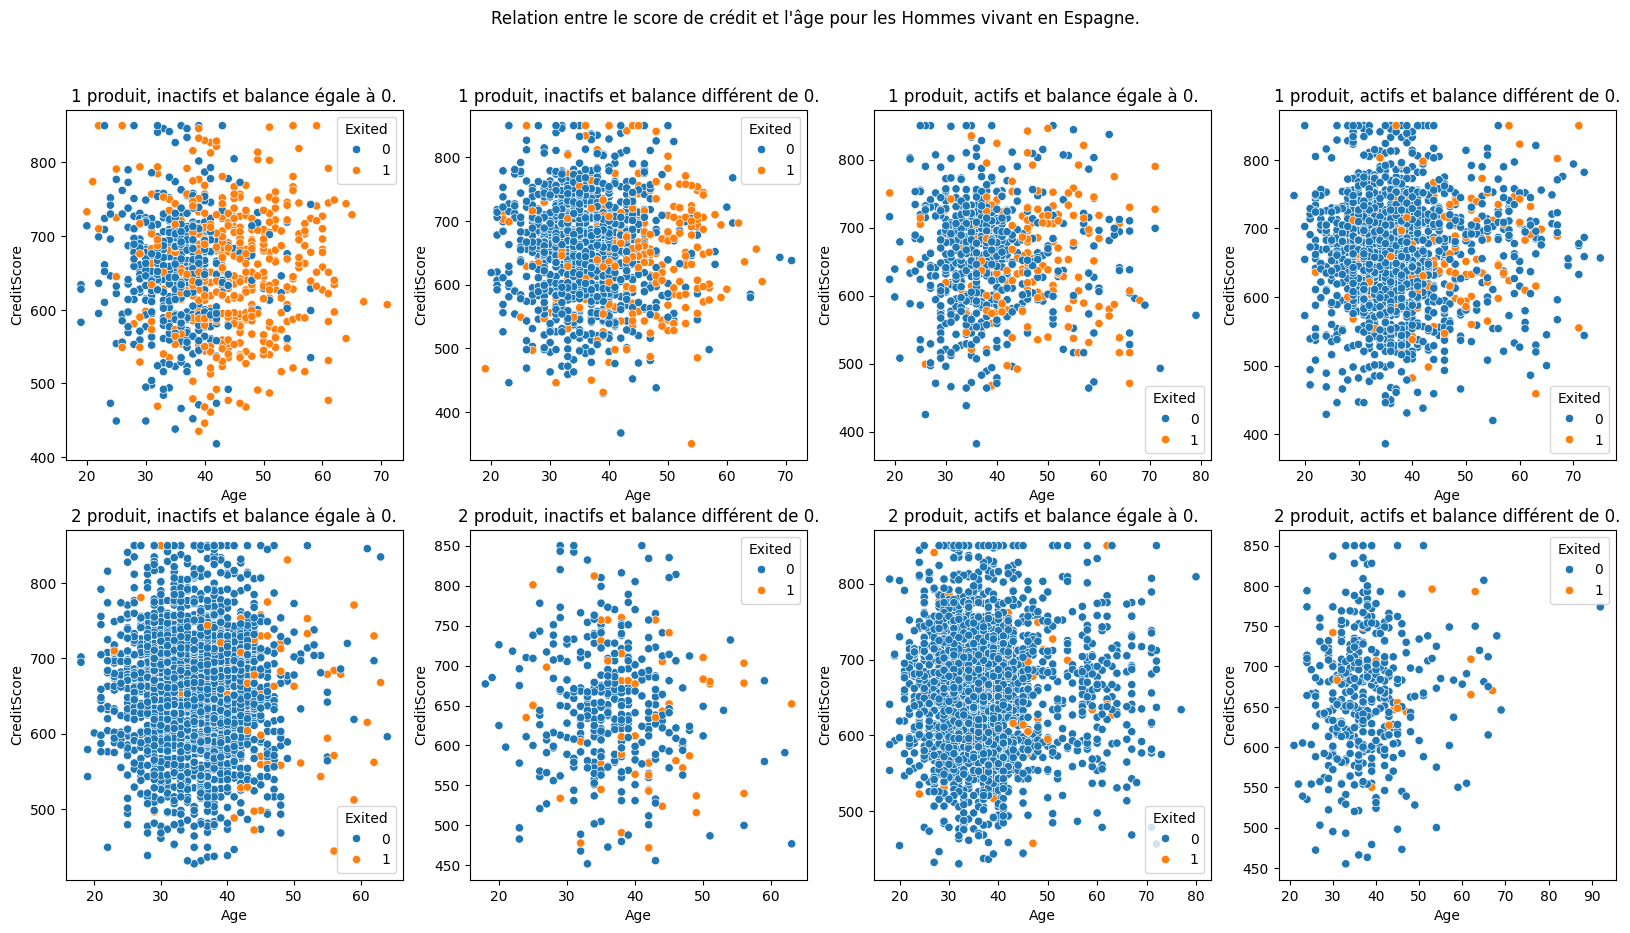

In [97]:
fig, ax = plt.subplots(2, 4)
fig.set_size_inches(20, 10)
plt.suptitle(
    "Relation entre le score de crédit et l'âge pour les Hommes vivant en Espagne."
)
ax[0, 0].set_title("1 produit, inactifs et balance égale à 0.")
ax[0, 1].set_title("1 produit, inactifs et balance différent de 0.")
ax[0, 2].set_title("1 produit, actifs et balance égale à 0.")
ax[0, 3].set_title("1 produit, actifs et balance différent de 0.")
ax[1, 0].set_title("2 produit, inactifs et balance égale à 0.")
ax[1, 1].set_title("2 produit, inactifs et balance différent de 0.")
ax[1, 2].set_title("2 produit, actifs et balance égale à 0.")
ax[1, 3].set_title("2 produit, actifs et balance différent de 0.")

sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Spain_Male_1_0.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 0],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Spain_Male_1_0.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 1],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Spain_Male_1_1.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 2],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Spain_Male_1_1.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[0, 3],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Spain_Male_2_0.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 0],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Spain_Male_2_0.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 1],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Spain_Male_2_1.0_0'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 2],
)
sns.scatterplot(
    data=train_set_copy.query("`Profil` == 'Spain_Male_2_1.0_1'"),
    x="Age",
    y="CreditScore",
    hue="Exited",
    ax=ax[1, 3],
)
plt.show()

On peut récupérer les clients qui ont 1 seul produit, inactifs et balance égale à 0 et qui ont plus de 39 ans. On peut aussi récupérer les clients qui ont 1 seul produit, inactifs et qui ont une balance différent de 0 et qui ont plus de 49 ans.

Maintenant on va faire une variable binaire dans lequel tous les clients qu'on va récupérer seront égale à 1 et les autres à 0.

In [98]:
condition_list = [
    (
        (train_set_copy["Profil"] == "France_Female_1_0.0_0")
        & (train_set_copy["Age"] >= 35)
    )
    | (
        (train_set_copy["Profil"] == "France_Female_1_0.0_1")
        & (train_set_copy["Age"] >= 40)
    )
    | (
        (train_set_copy["Profil"] == "France_Female_1_1.0_0")
        & (train_set_copy["Age"] >= 40)
    )
    | (
        (train_set_copy["Profil"] == "France_Male_1_0.0_0")
        & (train_set_copy["Age"] >= 40)
    )
    | (
        (train_set_copy["Profil"] == "France_Male_1_0.0_1")
        & (train_set_copy["Age"] >= 50)
    )
    | (
        (train_set_copy["Profil"] == "Germany_Female_1_0.0_1")
        & (train_set_copy["Age"] >= 38)
    )
    | (
        (train_set_copy["Profil"] == "Germany_Female_1_1.0_1")
        & (train_set_copy["Age"] >= 42)
    )
    | (
        (train_set_copy["Profil"] == "Germany_Male_1_0.0_1")
        & (train_set_copy["Age"] >= 40)
    )
    | (
        (train_set_copy["Profil"] == "Germany_Male_1_1.0_1")
        & (train_set_copy["Age"] >= 45)
        & (train_set_copy["Age"] <= 65)
    )
    | (
        (train_set_copy["Profil"] == "Spain_Female_1_0.0_0")
        & (train_set_copy["Age"] >= 35)
    )
    | (
        (train_set_copy["Profil"] == "Spain_Female_1_0.0_1")
        & (train_set_copy["Age"] >= 42)
    )
    | (
        (train_set_copy["Profil"] == "Spain_Female_1_1.0_0")
        & (train_set_copy["Age"] >= 42)
    )
    | (
        (train_set_copy["Profil"] == "Spain_Male_1_0.0_0")
        & (train_set_copy["Age"] >= 39)
    )
    | (
        (train_set_copy["Profil"] == "Spain_Male_1_0.0_1")
        & (train_set_copy["Age"] >= 49)
    )
]
train_set_copy["Exited_model"] = np.select(
    condlist=condition_list, choicelist=[1], default=0
)

pd.crosstab(train_set_copy["Exited_model"], train_set_copy["Exited"])

Exited,0,1
Exited_model,,
0,71964,7932
1,4064,9676


Voilà les meilleurs statistique qu'on peut obtenir avec un modéle linéaire. Mainteanat passons au préprocessing.

##III) Préprocessing

In [99]:
from sklearn import set_config
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score

X_train_set = train_set.drop("Exited", axis=1)
y_train_set = train_set["Exited"]
X_test_set = test_set.drop("Exited", axis=1)
y_test_set = test_set["Exited"]
set_config(transform_output="pandas")


def creation_profil(df):
    df["Profil"] = (
        df["Geography"]
        + "_"  # séparateur, au choix
        + df["Gender"]
        + "_"
        + df["NumOfProducts"].astype(str)
        + "_"
        + df["IsActiveMember"].astype(str)
        + "_"
        + df["Binary_balance"].astype(str)
    )
    return df


X_train_set = creation_profil(train_set)
X_train_set

,CustomerId,Surname,Age,Balance,CreditScore,EstimatedSalary,NumOfProducts,Tenure,Exited,Gender,Geography,HasCrCard,IsActiveMember,Binary_balance,Profil
0,15565701,Chineze,32,107210,705,129823,1,6,0,Male,France,1.0,1.0,1,France_Male_1_1.0_1
1,15565701,Ferri,39,161994,698,90212,1,2,0,Female,France,1.0,0.0,1,France_Female_1_0.0_1
2,15565706,Akobundu,35,0,663,83256,1,4,1,Male,Spain,1.0,1.0,0,Spain_Male_1_1.0_0
3,15565706,Chung,39,124577,699,160593,2,5,0,Male,Germany,1.0,0.0,1,Germany_Male_2_0.0_1
4,15565714,Cattaneo,47,64430,601,96518,2,1,0,Male,Spain,1.0,0.0,1,Spain_Male_2_0.0_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95356,15815690,Ch'iu,51,106302,661,85889,1,5,1,Male,Germany,1.0,0.0,1,Germany_Male_1_0.0_1
95357,15815690,Iweobiegbulam,45,0,620,192744,2,5,0,Male,France,0.0,1.0,0,France_Male_2_1.0_0
95358,15815690,K'ung,51,103176,707,171091,1,3,0,Male,Germany,1.0,1.0,1,Germany_Male_1_1.0_1
95359,15815690,Madukaego,31,0,652,151315,2,1,0,Female,France,1.0,1.0,0,France_Female_2_1.0_0


In [100]:
X_test_set = creation_profil(X_test_set)
X_test_set

,CustomerId,Surname,Age,Balance,CreditScore,EstimatedSalary,NumOfProducts,Tenure,Gender,Geography,HasCrCard,IsActiveMember,Binary_balance,Profil
0,15565706,Akobundu,37,0,682,83256,1,1,Male,France,1.0,1.0,0,France_Male_1_1.0_0
1,15565706,McGregor,34,0,564,53584,2,8,Male,France,0.0,1.0,0,France_Male_2_1.0_0
2,15565714,Yermakov,38,152390,595,87834,1,2,Male,France,1.0,1.0,1,France_Male_1_1.0_1
3,15565759,Uwakwe,59,106590,700,185600,1,8,Female,France,1.0,0.0,1,France_Female_1_0.0_1
4,15565796,Toscani,20,0,577,154776,1,2,Male,France,0.0,0.0,0,France_Male_1_0.0_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26372,15815615,Hs?,54,147292,702,56785,1,4,Female,France,1.0,1.0,1,France_Female_1_1.0_1
26373,15815620,Okwuoma,24,76954,516,27366,1,9,Male,France,0.0,0.0,1,France_Male_1_0.0_1
26374,15815640,Maclean,53,95712,660,57544,1,2,Female,France,1.0,1.0,1,France_Female_1_1.0_1
26375,15815645,Corrie,41,165272,635,60729,1,2,Male,France,1.0,1.0,1,France_Male_1_1.0_1


In [101]:
def create_condition(df):
    condition_list = [
        (df["NumOfProducts"] > 2)
        | ((df["Profil"] == "France_Female_1_0.0_0") & (df["Age"] >= 35))
        | ((df["Profil"] == "France_Female_1_0.0_1") & (df["Age"] >= 40))
        | ((df["Profil"] == "France_Female_1_1.0_0") & (df["Age"] >= 40))
        | ((df["Profil"] == "France_Male_1_0.0_0") & (df["Age"] >= 40))
        | ((df["Profil"] == "France_Male_1_0.0_1") & (df["Age"] >= 50))
        | ((df["Profil"] == "Germany_Female_1_0.0_1") & (df["Age"] >= 38))
        | ((df["Profil"] == "Germany_Female_1_1.0_1") & (df["Age"] >= 42))
        | ((df["Profil"] == "Germany_Male_1_0.0_1") & (df["Age"] >= 40))
        | (
            (df["Profil"] == "Germany_Male_1_1.0_1")
            & (df["Age"] >= 45)
            & (df["Age"] <= 65)
        )
        | ((df["Profil"] == "Spain_Female_1_0.0_0") & (df["Age"] >= 35))
        | ((df["Profil"] == "Spain_Female_1_0.0_1") & (df["Age"] >= 42))
        | ((df["Profil"] == "Spain_Female_1_1.0_0") & (df["Age"] >= 42))
        | ((df["Profil"] == "Spain_Male_1_0.0_0") & (df["Age"] >= 39))
        | ((df["Profil"] == "Spain_Male_1_0.0_1") & (df["Age"] >= 49))
    ]
    df["Exited_model"] = np.select(condlist=condition_list, choicelist=[1], default=0)
    return df


X_train_set = create_condition(X_train_set)
X_train_set

,CustomerId,Surname,Age,Balance,CreditScore,EstimatedSalary,NumOfProducts,Tenure,Exited,Gender,Geography,HasCrCard,IsActiveMember,Binary_balance,Profil,Exited_model
0,15565701,Chineze,32,107210,705,129823,1,6,0,Male,France,1.0,1.0,1,France_Male_1_1.0_1,0
1,15565701,Ferri,39,161994,698,90212,1,2,0,Female,France,1.0,0.0,1,France_Female_1_0.0_1,0
2,15565706,Akobundu,35,0,663,83256,1,4,1,Male,Spain,1.0,1.0,0,Spain_Male_1_1.0_0,0
3,15565706,Chung,39,124577,699,160593,2,5,0,Male,Germany,1.0,0.0,1,Germany_Male_2_0.0_1,0
4,15565714,Cattaneo,47,64430,601,96518,2,1,0,Male,Spain,1.0,0.0,1,Spain_Male_2_0.0_1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95356,15815690,Ch'iu,51,106302,661,85889,1,5,1,Male,Germany,1.0,0.0,1,Germany_Male_1_0.0_1,1
95357,15815690,Iweobiegbulam,45,0,620,192744,2,5,0,Male,France,0.0,1.0,0,France_Male_2_1.0_0,0
95358,15815690,K'ung,51,103176,707,171091,1,3,0,Male,Germany,1.0,1.0,1,Germany_Male_1_1.0_1,1
95359,15815690,Madukaego,31,0,652,151315,2,1,0,Female,France,1.0,1.0,0,France_Female_2_1.0_0,0


In [102]:
X_test_set = create_condition(X_test_set)
X_test_set

,CustomerId,Surname,Age,Balance,CreditScore,EstimatedSalary,NumOfProducts,Tenure,Gender,Geography,HasCrCard,IsActiveMember,Binary_balance,Profil,Exited_model
0,15565706,Akobundu,37,0,682,83256,1,1,Male,France,1.0,1.0,0,France_Male_1_1.0_0,0
1,15565706,McGregor,34,0,564,53584,2,8,Male,France,0.0,1.0,0,France_Male_2_1.0_0,0
2,15565714,Yermakov,38,152390,595,87834,1,2,Male,France,1.0,1.0,1,France_Male_1_1.0_1,0
3,15565759,Uwakwe,59,106590,700,185600,1,8,Female,France,1.0,0.0,1,France_Female_1_0.0_1,1
4,15565796,Toscani,20,0,577,154776,1,2,Male,France,0.0,0.0,0,France_Male_1_0.0_0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26372,15815615,Hs?,54,147292,702,56785,1,4,Female,France,1.0,1.0,1,France_Female_1_1.0_1,0
26373,15815620,Okwuoma,24,76954,516,27366,1,9,Male,France,0.0,0.0,1,France_Male_1_0.0_1,0
26374,15815640,Maclean,53,95712,660,57544,1,2,Female,France,1.0,1.0,1,France_Female_1_1.0_1,0
26375,15815645,Corrie,41,165272,635,60729,1,2,Male,France,1.0,1.0,1,France_Male_1_1.0_1,0


In [103]:
normalizer = ColumnTransformer(
    [
        ("standard", StandardScaler(), ["Age", "CreditScore"]),
        (
            "MinMax",
            MinMaxScaler(),
            ["Exited_model"],
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)
normalizer

ColumnTransformer(transformers=[('standard', StandardScaler(),
                                 ['Age', 'CreditScore']),
                                ('MinMax', MinMaxScaler(), ['Exited_model'])],
                  verbose_feature_names_out=False)

In [104]:
train_set_finale = normalizer.fit_transform(X_train_set)
train_set_finale

,Age,CreditScore,Exited_model
0,-0.715821,0.625762,0.0
1,0.103916,0.534606,0.0
2,-0.364505,0.078821,0.0
3,0.103916,0.547628,0.0
4,1.040759,-0.728569,0.0
...,...,...,...
95356,1.509181,0.052776,1.0
95357,0.806548,-0.481143,0.0
95358,1.509181,0.651807,1.0
95359,-0.832926,-0.064426,0.0


In [105]:
model = LogisticRegression(random_state=42)
param_grid = {
    "penalty": ["l1", "l2", "elasticnet", None],
    "class_weight": ["balanced", None],
    "solver": ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"],
}

grisearch = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="f1")
grisearch.fit(train_set_finale, y_train_set)
print(grisearch.best_params_)
print(grisearch.best_score_)

{'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}
0.6465298192763863


/home/florian/Bank-churn/bankChurn/.venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
110 fits failed out of a total of 240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/home/florian/Bank-churn/bankChurn/.venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/florian/Bank-churn/bankChurn/.venv/lib/python3.10/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/florian/Bank-churn/bankChurn/.venv/lib/python3.10/site-packages/sklearn/

In [106]:
X_test_set = normalizer.transform(X_test_set)
best_model = grisearch.best_estimator_
y_pred = best_model.predict(X_test_set)
test_f1 = f1_score(y_test_set, y_pred)
test_f1

0.6382804503582395

In [107]:
kaggle_test_set = pd.read_csv("test_data.csv")
kaggle_test_set.head()

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,67897,15585246,Bancks,585,France,Female,53.0,2,0.00,2,1.0,1.0,91830.75
1,163075,15604551,Robb,606,France,Male,24.0,2,0.00,1,0.0,1.0,90876.95
2,134760,15729040,Ugochukwu,633,Germany,Male,44.0,1,118907.60,1,1.0,0.0,47777.15
3,68707,15792329,Hs?,602,Germany,Male,40.0,2,149961.99,2,1.0,1.0,82696.84
4,3428,15617166,Genovesi,645,France,Male,31.0,4,132351.29,1,1.0,0.0,151887.16


In [108]:
kaggle_test_set["Binary_balance"] = np.select(
    condlist=[kaggle_test_set["Balance"] != 0], choicelist=[1], default=0
)
kaggle_test_set = creation_profil(kaggle_test_set)
kaggle_test_set = create_condition(kaggle_test_set)
kaggle_test_set_finale = normalizer.transform(kaggle_test_set)
kaggle_test_set_finale

,Age,CreditScore,Exited_model
0,1.743391,-0.936928,0.0
1,-1.652664,-0.663457,0.0
2,0.689443,-0.311852,1.0
3,0.221022,-0.715546,0.0
4,-0.832926,-0.155583,0.0
...,...,...,...
21450,-0.364505,0.365314,0.0
21451,1.040759,-0.116515,1.0
21452,-0.715821,-0.650434,0.0
21453,2.094707,0.625762,1.0


In [109]:
best_model = grisearch.best_estimator_

ypred = best_model.predict(kaggle_test_set_finale)
ypred

array([0, 0, 1, ..., 0, 1, 0], shape=(21455,))

In [110]:
results = pd.DataFrame({"ID": kaggle_test_set["ID"], "Exited": ypred})
results.set_index("ID")

,Exited
ID,
67897,0
163075,0
134760,1
68707,0
3428,0
...,...
24790,0
152608,1
28134,0


In [111]:
results.to_csv("submission.csv")

On arrive à la fin avec ce modéle linéaire à un score de 62,400 % qui reste insuffisant mais pour un modéle linéaire cela reste un bon score. Ce modéle constitue notre benchmark.